# Импорты

In [189]:
from tqdm import TqdmWarning
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")
warnings.filterwarnings("ignore", category=TqdmWarning)

import math
import optuna

import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from pandas import Series
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
import ahpy
import pickle
from sklearn.model_selection import train_test_split

Давайте ознакомимся с нашими данными, выполнив предварительный анализ данных.

In [190]:
# Загрузка данных
df_train = pd.read_csv('../../data/cardio_100.csv')

# Первичный осмотр данных
df_train.info()
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           100000 non-null  int64  
 1   age          100000 non-null  int64  
 2   gender       100000 non-null  int64  
 3   height       100000 non-null  int64  
 4   weight       100000 non-null  float64
 5   ap_hi        100000 non-null  int64  
 6   ap_lo        100000 non-null  int64  
 7   cholesterol  100000 non-null  int64  
 8   gluc         100000 non-null  int64  
 9   smoke        100000 non-null  int64  
 10  alco         100000 non-null  int64  
 11  active       100000 non-null  int64  
 12  cardio       100000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 9.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [191]:
# Удаление колонки 'id'
df_train.drop('id', axis=1, inplace=True)

In [192]:
# Преобразование возраста из дней в года (без дробной части)
df_train['age'] = (df_train['age'] / 365.25).astype(int)

In [193]:
# Для выявления возможных аномальных значений необходимо с помощью метода 'describe' ознакомится с количественными данными.
numeric_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
df_train[numeric_columns].describe()

,age,height,weight,ap_hi,ap_lo
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,52.792160,164.348140,74.180167,129.253490,96.347990
std,6.770516,8.211187,14.379494,173.639687,181.437372
min,24.000000,50.000000,10.000000,-150.000000,-90.000000
25%,48.000000,159.000000,65.000000,120.000000,80.000000
50%,53.000000,165.000000,72.000000,120.000000,80.000000
75%,58.000000,170.000000,82.000000,140.000000,90.000000
max,64.000000,250.000000,200.000000,16020.000000,11000.000000


# Возраст (age):

Средний возраст составляет около 52.79 лет, что указывает на взрослую популяцию.
Минимальный возраст 24 года, максимальный — 64 года. Это предполагает, что данные ограничены взрослым населением и не включают очень молодых или очень старых людей.

# Рост (height):

Средний рост — 164.35 см, что кажется разумным для взрослого населения.
Однако минимальный рост 50 см и максимальный 250 см кажутся аномальными и могут указывать на ошибки ввода данных или выбросы.

# Вес (weight):

Средний вес — 74.18 кг, что входит в нормальный диапазон для взрослого человека.
Минимальный вес 10 кг и максимальный 200 кг — минимальный вес крайне нереалистичен для взрослых, что также может быть ошибкой ввода.

# Артериальное давление (ap_hi и ap_lo):

Средние значения систолического (129.25) и диастолического (96.35) давления находятся в пределах ожидаемого диапазона.
Минимальные значения (-150 для ap_hi и -90 для ap_lo) и максимальные значения (16020 для ap_hi и 11000 для ap_lo) являются явными выбросами. Это указывает на серьезные ошибки в данных, которые могут значительно исказить любой анализ. Такие значения могут возникнуть из-за ошибок ввода или сбоев в процессе сбора данных.

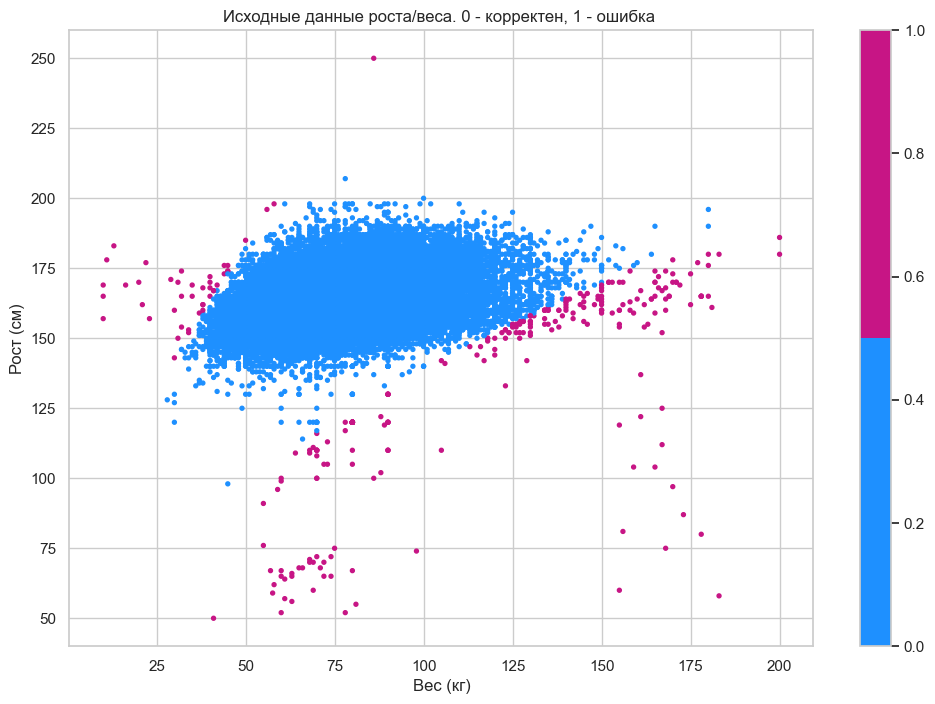

In [194]:
all_data_input = df_train
all_data_input['imt'] = all_data_input.weight / (np.square(all_data_input.height) / 10000)

plt.figure(figsize=(12, 8))
plt.scatter(all_data_input.weight, all_data_input.height, 
            c=((all_data_input.imt < 15) | (all_data_input.imt > 52)), s = 8, 
            cmap=ListedColormap(['dodgerblue','mediumvioletred']))
plt.colorbar()
plt.title('Исходные данные роста/веса. 0 - корректен, 1 - ошибка ')
plt.xlabel('Вес (кг)')
plt.ylabel('Рост (см)')

del all_data_input

In [195]:
def deviate_weight_height(Data, min_imt = 15, max_imt=52, coef_height = 24, coef_weight = 24, coef_age = 720):
        """Обработка некорректных данных в Data в столбцах 'weight', 'height'
        --------
        Некорректными считались данные пациентов, у которых Индекс Массы Тела -
        ИМТ < min_imt (дистрофия)или ИМТ > max_imt (сверх ожирение)
        --------
        Параметры
        --------
        * max_imt - максимальный индекс ИМТ, говорящий об ожирении
        * min_imt - минимальный индекс ИМТ, говорящий о дистрофии
        * coef_height - ИМТ для рассчета веса по росту
        * coef_weight - ИМТ для рассчета роста по весу
        * coef_age - допустимый отступ от реального возраста влево/вправо для взятия среднего по росту и весу
        """

        tmp_Data = Data.copy()
        # переводим рост в метры
        tmp_Data['height'] /= 100
        tmp_Data['imt'] = tmp_Data['weight'] / (tmp_Data['height'] * tmp_Data['height'])
        # выбор строк с некорректными данными
        dev_Data = tmp_Data[(tmp_Data['imt'] > max_imt) | (tmp_Data['imt'] < min_imt)]
        # выбор строк с корректными данными
        not_dev_Data = tmp_Data[(tmp_Data['imt'] < max_imt) | (tmp_Data['imt'] > min_imt)]

        new_weight = []
        new_height = []
        
        for imt, weight, height, age in zip(dev_Data['imt'],dev_Data['weight'], dev_Data['height'], dev_Data['age']):
            # если рост - нормальный, рассчитываем вес по росту
            if height > 1.20 and height < 2.30:
                weight = coef_height * height * height
            # если вес - нормальный, рассчитываем рост по весу
            elif weight > 30 and weight < 120:
                height = math.sqrt(weight / coef_weight)
            # иначе берем средний рост и вес по пациентам, возраст которых +- 2 года от возраста нашего пациента
            else:
                filter_Data = not_dev_Data[(not_dev_Data['age'] < age + coef_age) &
                                            (not_dev_Data['age'] > age - coef_age)]
                height = filter_Data['height'].mean()
                weight = filter_Data['weight'].mean()
                
            new_height.append(height)
            new_weight.append(weight)

        # изменяем некорректные значения на скорректированные
        mask = (tmp_Data['imt'] > max_imt) | (tmp_Data['imt'] < min_imt)
        
        tmp_Data.loc[mask, 'height'] = Series(new_height, index=dev_Data.index)
        tmp_Data.loc[mask, 'weight'] = Series(new_weight, index=dev_Data.index)
        # переводим рост в сантиметры
        tmp_Data['height'] *= 100
        # удаляем вставленный столбец с ИМТ
        tmp_Data = tmp_Data.drop('imt', axis=1)
        return tmp_Data

In [196]:
df_train = deviate_weight_height(df_train, max_imt=52, min_imt=15)

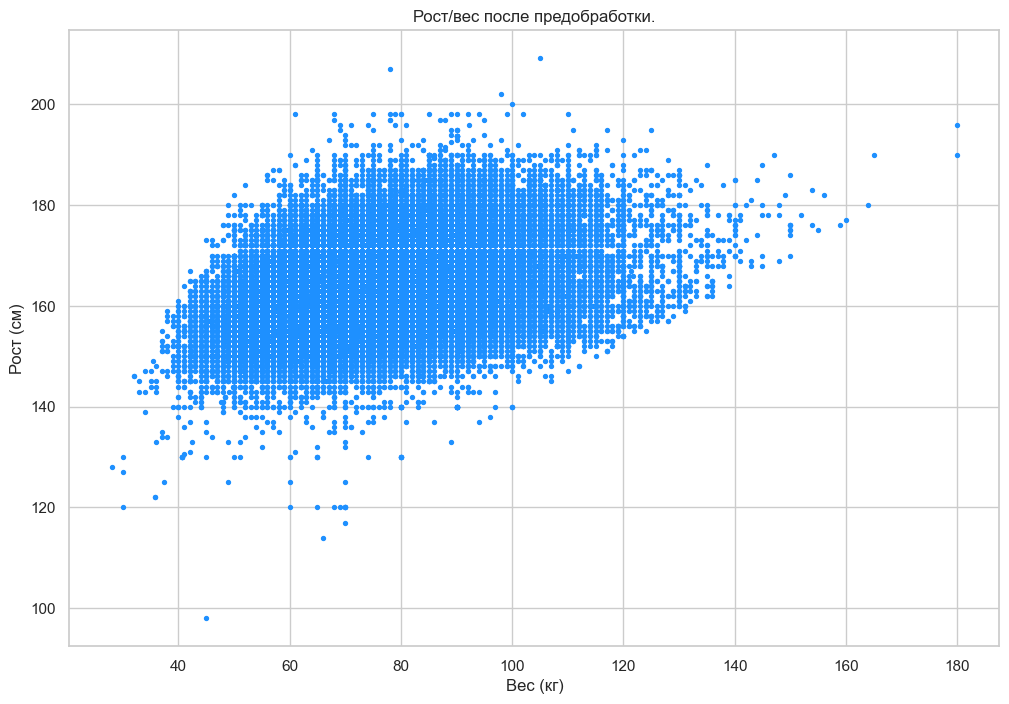

In [197]:
plt.figure(figsize=(12, 8))
all_data_normal_weight_height = df_train
plt.scatter(all_data_normal_weight_height.weight, all_data_normal_weight_height.height, s = 8, c = 'dodgerblue')
plt.title('Рост/вес после предобработки.')
plt.xlabel('Вес (кг)')
plt.ylabel('Рост (см)')
del all_data_normal_weight_height

Text(0, 0.5, 'Верхнее давление (мм. рт. ст.)')

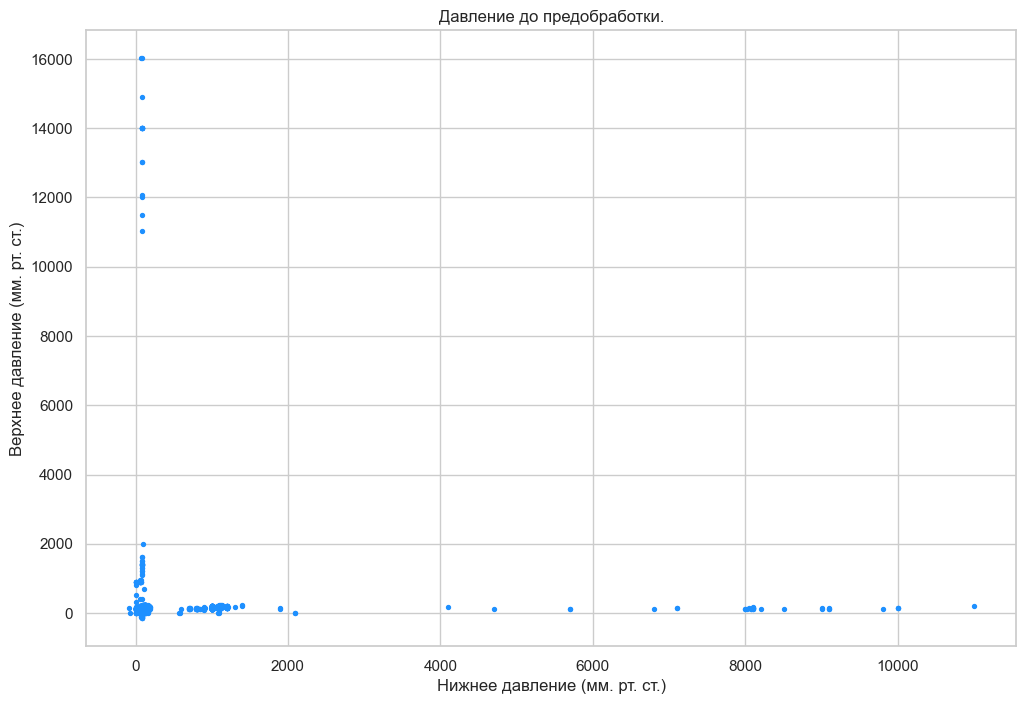

In [198]:
# По признакам ap_lo и ap_hi есть аномальные значения. Обработаем такие аномалии.
plt.figure(figsize=(12, 8))
plt.scatter(df_train.ap_lo, df_train.ap_hi, s = 8, c = 'dodgerblue')
plt.title('Давление до предобработки.')
plt.xlabel('Нижнее давление (мм. рт. ст.)')
plt.ylabel('Верхнее давление (мм. рт. ст.)')

In [199]:
def deviate_arterial_pressure(Data):
    """Обработка некорректных данных в Data в столбцах 'ap_hi', 'ap_lo'."""
    # работаем с копией, чтобы не менять исходный DataFrame (опционально)
    df_abs = Data.copy()
    
    # перевод отрицательных значений в положительные целые
    df_abs[['ap_hi', 'ap_lo']] = df_abs[['ap_hi', 'ap_lo']].abs().astype(int)

    # маска для некорректных значений
    mask = (df_abs['ap_hi'] > 300) | (df_abs['ap_hi'] < 30) | (df_abs['ap_lo'] > 200) | (df_abs['ap_lo'] < 10)
    
    # если нет некорректных данных – сразу возвращаем
    if not mask.any():
        return df_abs

    dev_data = df_abs.loc[mask, ['ap_hi', 'ap_lo']].copy()

    # средние нормальные давления (округляем до целых)
    ap_hi_mean = int(round(df_abs['ap_hi'].mean()))
    ap_lo_mean = int(round(df_abs['ap_lo'].mean()))

    new_ap_hi = []
    new_ap_lo = []
    
    for ap_hi, ap_lo in zip(dev_data['ap_hi'], dev_data['ap_lo']):
        err_flag = True

        # оба давления в норме
        if 30 < ap_hi < 300 and 10 < ap_lo < 200 and ap_hi > ap_lo:
            err_flag = False
            new_ap_hi.append(ap_hi)
            new_ap_lo.append(ap_lo)

        # верхнее норма, нижнее большое (160/1100 -> 160/110)
        elif 30 < ap_hi < 300 and ap_lo > 200:
            tmp_ap_hi, tmp_ap_lo = ap_hi, ap_lo
            f = True
            while len(str(ap_lo)) > 1:
                ap_lo //= 10
                if ap_lo < 200 and ap_hi > ap_lo:
                    f = False
                    err_flag = False
                    new_ap_lo.append(ap_lo)
                    new_ap_hi.append(ap_hi)
                    break
            if f:
                ap_hi, ap_lo = tmp_ap_hi, tmp_ap_lo

        # верхнее большое, нижнее норма (1600/90 -> 160/90)
        elif ap_hi > 300 and 10 < ap_lo < 200:
            tmp_ap_hi, tmp_ap_lo = ap_hi, ap_lo
            f = True
            while len(str(ap_hi)) > 1:
                ap_hi //= 10
                if ap_hi < 300 and ap_hi > ap_lo:
                    f = False
                    err_flag = False
                    new_ap_lo.append(ap_lo)
                    new_ap_hi.append(ap_hi)
                    break
            if f:
                ap_hi, ap_lo = tmp_ap_hi, tmp_ap_lo

        # верхнее большое, нижнее малое (906/0 -> 90/60)
        elif ap_hi > 300 and ap_lo < 10:
            mod = ap_hi % 10
            ap_hi //= 10
            ap_lo = int(str(mod) + str(ap_lo))
            if ap_hi < 300 and ap_lo > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # верхнее малое, нижнее большое (9/770 -> 97/70)
        elif ap_hi < 30 and ap_lo > 200:
            len_ap_lo = len(str(ap_lo))
            first_digit = ap_lo // (10 ** (len_ap_lo - 1))
            ap_lo = ap_lo % (10 ** (len_ap_lo - 1))
            ap_hi = int(str(ap_hi) + str(first_digit))
            if ap_hi < 300 and ap_lo > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # верхнее норма, нижнее малое (120/8 -> 120/80)
        elif 30 < ap_hi < 300 and ap_lo < 10 and ap_lo != 0:
            ap_lo *= 10
            if ap_lo > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # верхнее малое, нижнее норма (8/60 -> 80/60)
        elif ap_hi < 30 and 10 < ap_lo < 200 and ap_hi != 0:
            ap_hi *= 10
            if ap_hi > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # ошибка не исправлена
        if err_flag:
            # оба давления в норме, но переставлены местами
            if 30 < ap_hi < 300 and 10 < ap_lo < 200 and ap_hi < ap_lo:
                ap_hi, ap_lo = ap_lo, ap_hi
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)
            # верхнее норма, нижнее отклонение – замена нижнего средним
            elif 30 < ap_hi < 300:
                subset = df_abs.loc[df_abs['ap_hi'] == ap_hi, 'ap_lo']
                ap_lo = int(round(subset.mean())) if not subset.empty else ap_lo_mean
                if ap_hi < ap_lo:
                    ap_hi, ap_lo = ap_lo, ap_hi
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)
            # нижнее норма, верхнее отклонение – замена верхнего средним
            elif 10 < ap_lo < 200:
                subset = df_abs.loc[df_abs['ap_lo'] == ap_lo, 'ap_hi']
                ap_hi = int(round(subset.mean())) if not subset.empty else ap_hi_mean
                if ap_hi < ap_lo:
                    ap_hi, ap_lo = ap_lo, ap_hi
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)
            # всё плохо – заменяем средними по выборке
            else:
                new_ap_lo.append(ap_lo_mean)
                new_ap_hi.append(ap_hi_mean)

    # Приведение к целым (на всякий случай)
    new_ap_hi = [int(round(x)) for x in new_ap_hi]
    new_ap_lo = [int(round(x)) for x in new_ap_lo]

    ap_lo_series = Series(new_ap_lo, index=dev_data.index)
    ap_hi_series = Series(new_ap_hi, index=dev_data.index)

    # Замена неверных значений исправленными по той же маске
    df_abs.loc[mask, 'ap_hi'] = ap_hi_series
    df_abs.loc[mask, 'ap_lo'] = ap_lo_series

    return df_abs

In [200]:
df_train = deviate_arterial_pressure(df_train)

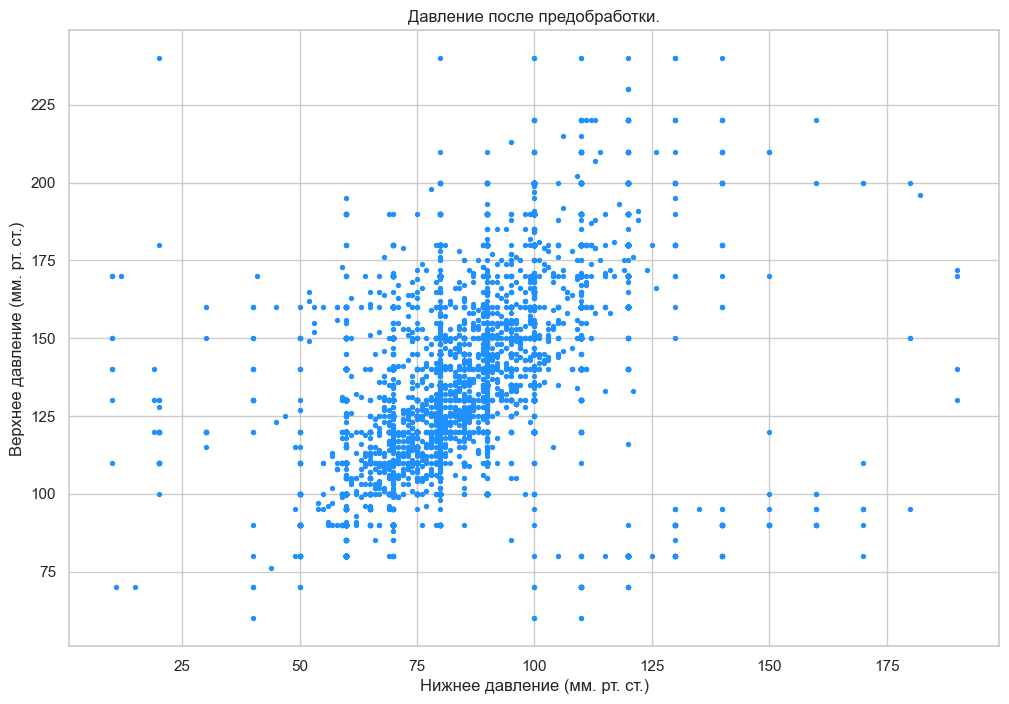

In [201]:
all_data_normal_pressure = df_train 

plt.figure(figsize=(12, 8))
plt.scatter(all_data_normal_pressure.ap_lo, all_data_normal_pressure.ap_hi, s = 8, c = 'dodgerblue')
plt.title('Давление после предобработки.')
plt.xlabel('Нижнее давление (мм. рт. ст.)')
plt.ylabel('Верхнее давление (мм. рт. ст.)')

del all_data_normal_pressure

In [202]:
# Выбираем все столбцы с типом float и преобразуем их в int
df_train_float_columns = df_train.select_dtypes(include=['float']).columns
df_train[df_train_float_columns] = df_train[df_train_float_columns].astype(int)

# Выбираем все столбцы с типом int64 и преобразуем их в int32
df_train_int64_columns = df_train.select_dtypes(include=['int64']).columns

# Преобразуем выбранные столбцы
df_train[df_train_int64_columns] = df_train[df_train_int64_columns].astype('int32')

# Проверяем результат
print(df_train.dtypes)

age            int32
gender         int32
height         int32
weight         int32
ap_hi          int32
ap_lo          int32
cholesterol    int32
gluc           int32
smoke          int32
alco           int32
active         int32
cardio         int32
dtype: object


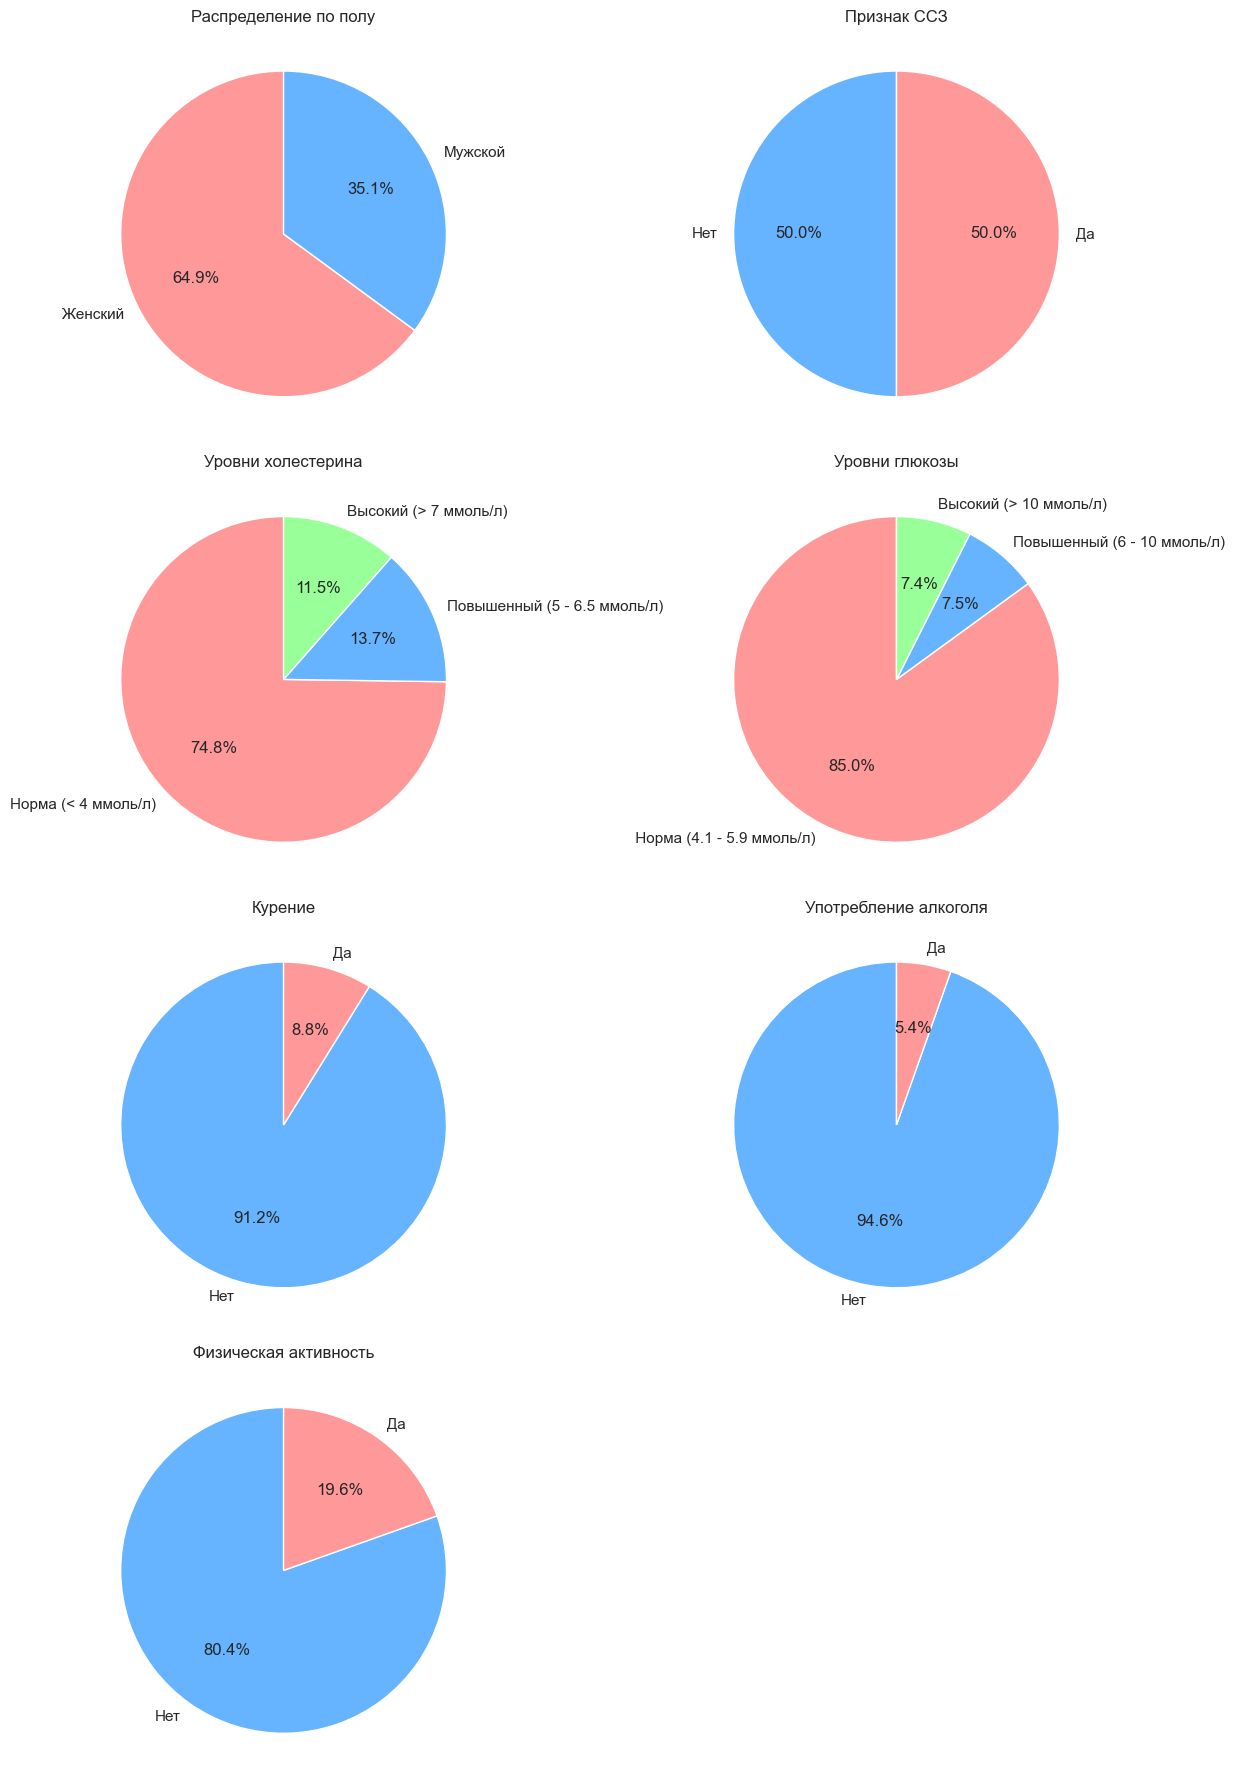

In [203]:
# Функция для создания круговой диаграммы
def plot_pie(column, labels, colors, title, ax):
    data = df_train[column].value_counts(normalize=True)
    ax.pie(data, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(title)

# Настройка цветов и меток для различных переменных
colors_binary = ['#66b3ff', '#ff9999']
labels_binary = ['Нет', 'Да']

fig, axs = plt.subplots(4, 2, figsize=(12, 18))  # Настройка сетки для вывода графиков

# Построение диаграмм для различных переменных
plot_pie('gender', ['Женский', 'Мужской'], ['#ff9999','#66b3ff'], 'Распределение по полу', axs[0, 0])
plot_pie('cardio', labels_binary, colors_binary, 'Признак ССЗ', axs[0, 1])
plot_pie('cholesterol', ['Норма (< 4 ммоль/л)', 'Повышенный (5 - 6.5 ммоль/л)', 'Высокий (> 7 ммоль/л)'], ['#ff9999', '#66b3ff', '#99ff99'], 'Уровни холестерина', axs[1, 0])
plot_pie('gluc', [' Норма (4.1 - 5.9 ммоль/л)', 'Повышенный (6 - 10 ммоль/л)', 'Высокий (> 10 ммоль/л)'], ['#ff9999', '#66b3ff', '#99ff99'], 'Уровни глюкозы', axs[1, 1])
plot_pie('smoke', labels_binary, colors_binary, 'Курение', axs[2, 0])
plot_pie('alco', labels_binary, colors_binary, 'Употребление алкоголя', axs[2, 1])
plot_pie('active', labels_binary, colors_binary, 'Физическая активность', axs[3, 0])

# Удаление лишних осей, если они есть
for i in range(4):
    for j in range(2):
        if not axs[i, j].has_data():
            fig.delaxes(axs[i][j])

plt.tight_layout()
plt.show()

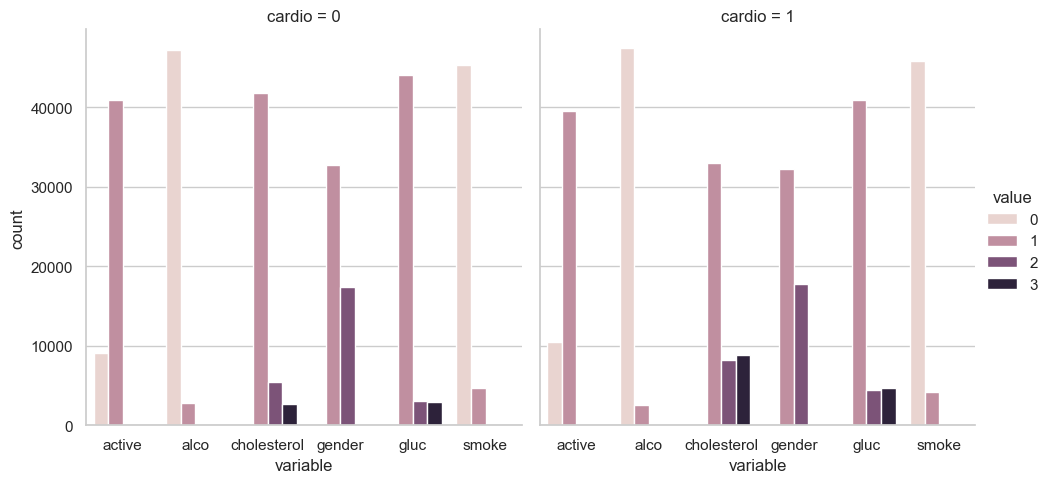

In [204]:
# Анализ уникальности значений cardio 
df_uniques = pd.melt(
    frame=df_train,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active"],
    id_vars=["cardio"]
)

# Группировка и подсчёт значений
df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value", "cardio"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

# Визуализация данных
g = sns.catplot(
    x="variable",
    y="count",
    hue="value",
    col="cardio",
    data=df_uniques,
    kind="bar",
    height=5,  
    aspect=1 
)


plt.show()

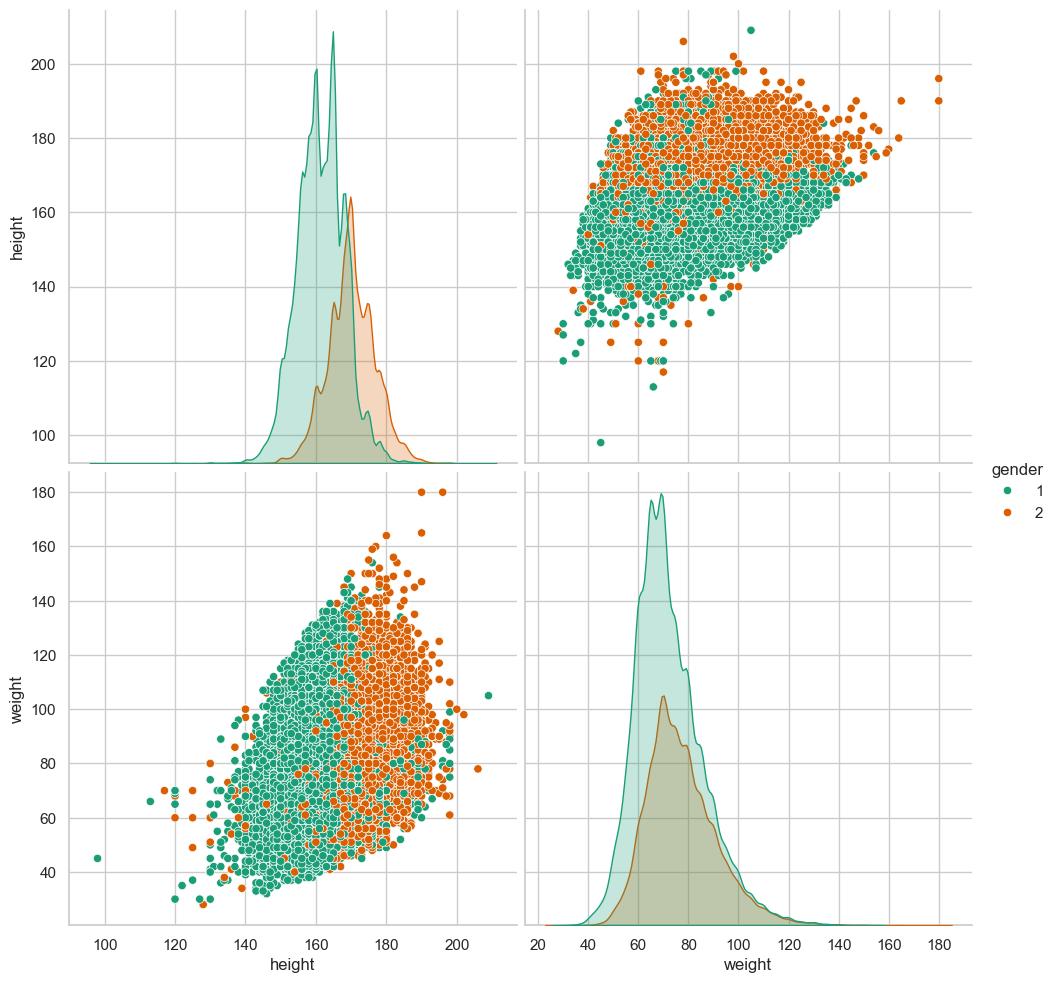

In [205]:
sns.pairplot(df_train[['height', 'weight', 'gender']], hue='gender', height=5, palette='Dark2');

In [206]:
# Вычислить средний рост для каждой группы гендера
average_heights = df_train.groupby('gender')['height'].mean()

print("Средний рост по группам гендера:")
print(average_heights)

# Определение, какой гендер выше
if average_heights[1] > average_heights[2]:
    print("Гендер '1' - мужчины, Гендер '2' - женщины")
    males = df_train[df_train['gender'] == 1]
    females = df_train[df_train['gender'] == 2]
else:
    print("Гендер '2' - мужчины, Гендер '1' - женщины")
    males = df_train[df_train['gender'] == 2]
    females = df_train[df_train['gender'] == 1]

# Подсчет количества мужчин и женщин
num_males = males.shape[0]
num_females = females.shape[0]

print(f"Количество мужчин: {num_males}, Количество женщин: {num_females}")

Средний рост по группам гендера:
gender
1    161.417465
2    170.002366
Name: height, dtype: float64
Гендер '2' - мужчины, Гендер '1' - женщины
Количество мужчин: 35082, Количество женщин: 64918


In [207]:
# Считаем количество людей, употребляющих алкоголь по полам
alcohol_consumption = df_train.groupby('gender')['alco'].sum()

# Вычисление общего количества мужчин и женщин в наборе данных
total_by_gender = df_train['gender'].value_counts()

# Вычисление процентного соотношения употребления алкоголя по полам
percentage_alcohol = (alcohol_consumption / total_by_gender) * 100

# Вывод результатов
print("Процент потребления алкоголя по полам:")
print(percentage_alcohol)

# Определяем, кто чаще употребляет алкоголь
if percentage_alcohol[1] > percentage_alcohol[2]:
    print("Женщины чаще сообщают о потреблении алкоголя.")
else:
    print("Мужчины чаще сообщают о потреблении алкоголя.")

Процент потребления алкоголя по полам:
gender
1     2.606365
2    10.609429
dtype: float64
Мужчины чаще сообщают о потреблении алкоголя.


In [208]:
# Считаем количество курильщиков по полам
smokers = df_train.groupby('gender')['smoke'].sum()

# Вычисление общего количества мужчин и женщин в наборе данных
total_by_gender = df_train['gender'].value_counts()

# Вычисление процентного соотношения курильщиков по полам
percentage_smokers = (smokers / total_by_gender) * 100

# Вывод результатов
print("Процент курильщиков по полам:")
print(percentage_smokers.round())

# Определение разницы в процентном соотношении курильщиков между мужчинами и женщинами
difference = abs(percentage_smokers[1] - percentage_smokers[2])

print(f"Разница между процентным соотношением курильщиков среди мужчин и женщин: {round(difference)}%")


Процент курильщиков по полам:
gender
1     2.0
2    22.0
dtype: float64
Разница между процентным соотношением курильщиков среди мужчин и женщин: 20%


Можно сделать вывод, что 1 закодированы 'женщины' (так в среднем их рост и вес чуть ниже, чем у мужчин), а 2 - 'мужчины'.

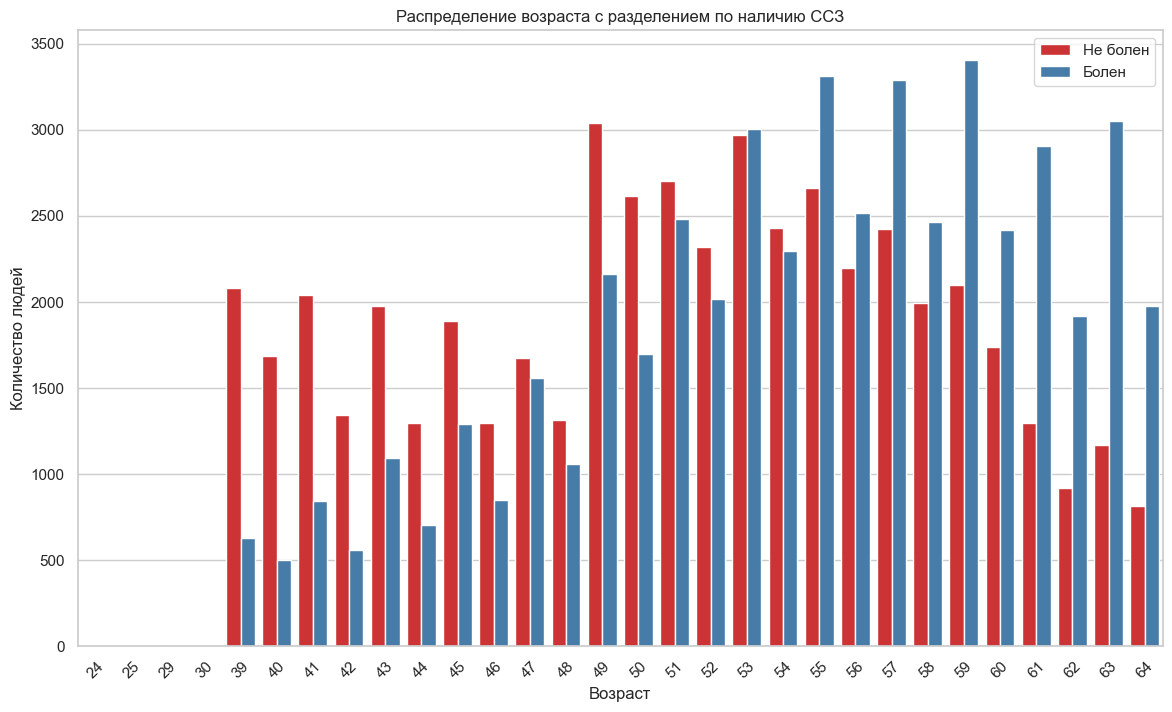

In [209]:
# Анализ распределения возраста по наличию ССЗ

plt.figure(figsize=(14, 8))  # Установка размера фигуры
sns.countplot(x='age', hue='cardio', data=df_train, palette='Set1')
plt.title('Распределение возраста с разделением по наличию ССЗ')
plt.xlabel('Возраст')
plt.ylabel('Количество людей')
plt.xticks(rotation=45)  # Поворот подписей оси X для лучшей видимости
plt.legend(labels=['Не болен', 'Болен'])
plt.show()


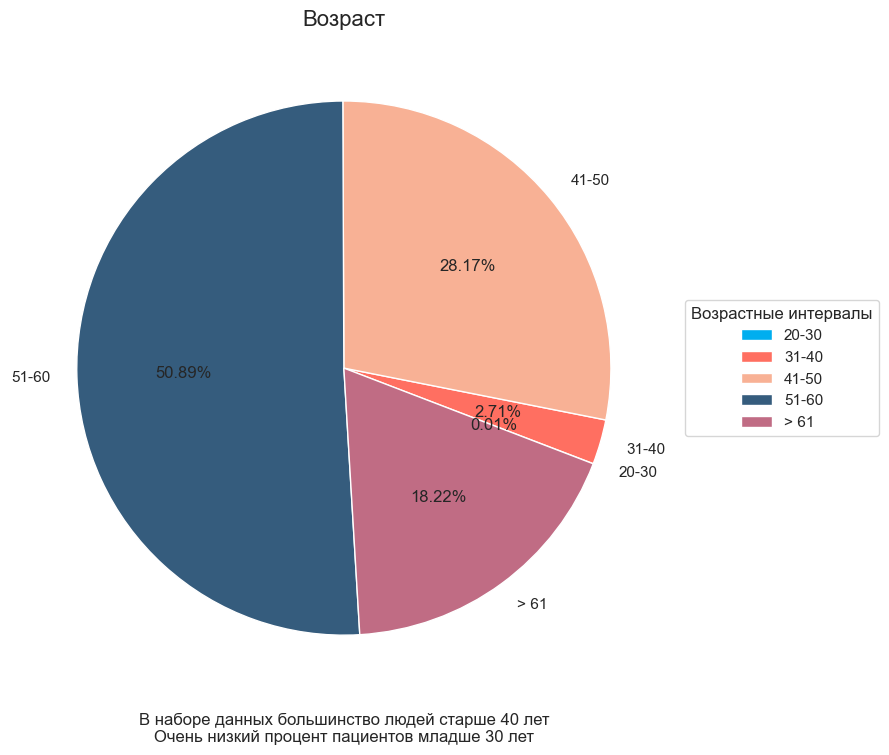

In [210]:
# Подсчитываем количество по возрастным группам
# Создаем категорию возрастных интервалов
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-30', '31-40', '41-50', '51-60', '> 61']
df_train['age_group'] = pd.cut(df_train['age'], bins=bins, labels=labels, right=False)

age_group_counts = df_train['age_group'].value_counts().sort_index()
colors_age = ['#00AEEF', '#FF6F61', '#F8B195', '#355C7D', '#C06C84', '#F67280']

fig, ax = plt.subplots(figsize=(12, 8)) 

wedges, texts, autotexts = ax.pie(age_group_counts, labels=age_group_counts.index, colors=colors_age, autopct='%1.2f%%', startangle=339)
ax.set_title('Возраст', fontsize=16)

# Добавляем пояснительный текст
ax.text(0, -1.4, "В наборе данных большинство людей старше 40 лет\nОчень низкий процент пациентов младше 30 лет", fontsize=12, ha='center')

# Добавляем легенду
ax.legend(wedges, labels, title="Возрастные интервалы", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()
df_train.drop('age_group', axis=1, inplace=True)

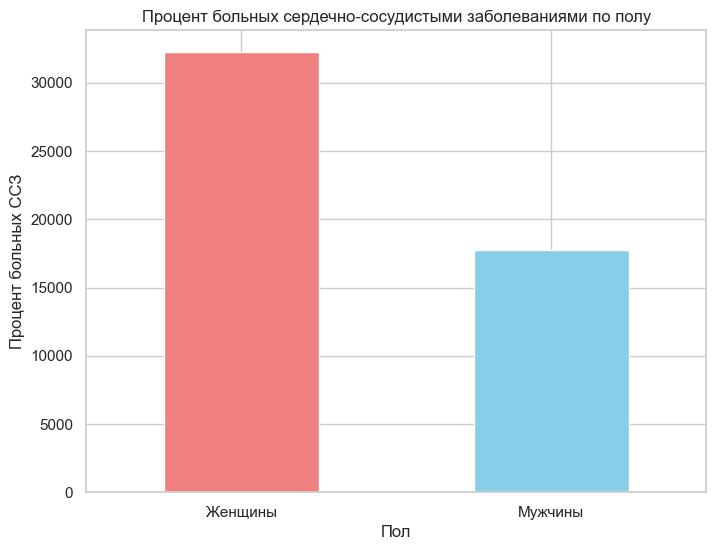

In [211]:
# Установка стиля
sns.set_theme(style="whitegrid")

# Подготовка данных
# Считаем количество больных и здоровых по полам
cardio_counts = df_train.groupby(['gender', 'cardio']).size().unstack(fill_value=0)


# Создание столбчатой диаграммы
fig, ax = plt.subplots(figsize=(8, 6))
cardio_counts[1].plot(kind='bar', color=['lightcoral', 'skyblue'], ax=ax)  # 1 - болеет
ax.set_ylabel('Процент больных ССЗ')
ax.set_xlabel('Пол')
ax.set_title('Процент больных сердечно-сосудистыми заболеваниями по полу')
ax.set_xticklabels(['Женщины', 'Мужчины'], rotation=0)


# Показать график
plt.show()


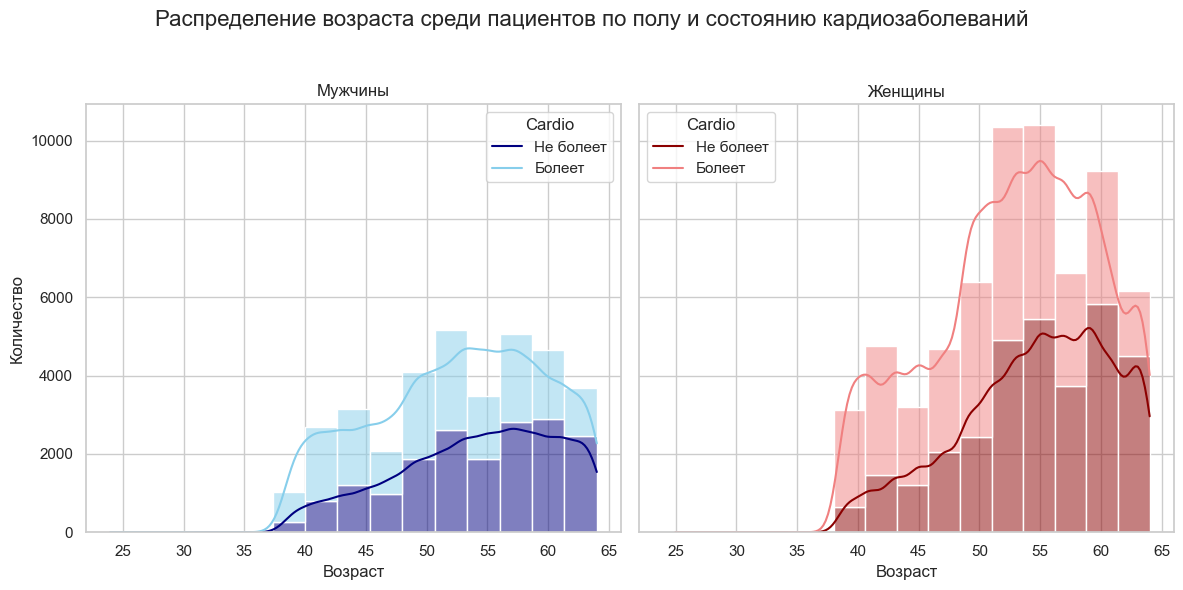

In [212]:
sns.set_theme(style="whitegrid")

fig, (ax_male, ax_female) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Мужчины
sns.histplot(data=df_train[df_train['gender'] == 2], x='age', hue='cardio', kde=True,
             palette=['skyblue', 'navy'], ax=ax_male, bins=15, multiple="stack")
ax_male.set_title('Мужчины')
ax_male.set_xlabel('Возраст')
ax_male.set_ylabel('Количество')
# Легенда создаётся автоматически, можно перенастроить её местоположение при необходимости
ax_male.legend(title='Cardio', labels=['Не болеет', 'Болеет'], loc='upper right')

# Женщины
sns.histplot(data=df_train[df_train['gender'] == 1], x='age', hue='cardio', kde=True,
             palette=['lightcoral', 'darkred'], ax=ax_female, bins=15, multiple="stack")
ax_female.set_title('Женщины')
ax_female.set_xlabel('Возраст')
ax_female.set_ylabel('')
ax_female.legend(title='Cardio', labels=['Не болеет', 'Болеет'], loc='upper left')

# Общий заголовок
fig.suptitle('Распределение возраста среди пациентов по полу и состоянию кардиозаболеваний', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # rect оставляет место для общего заголовка
plt.show()

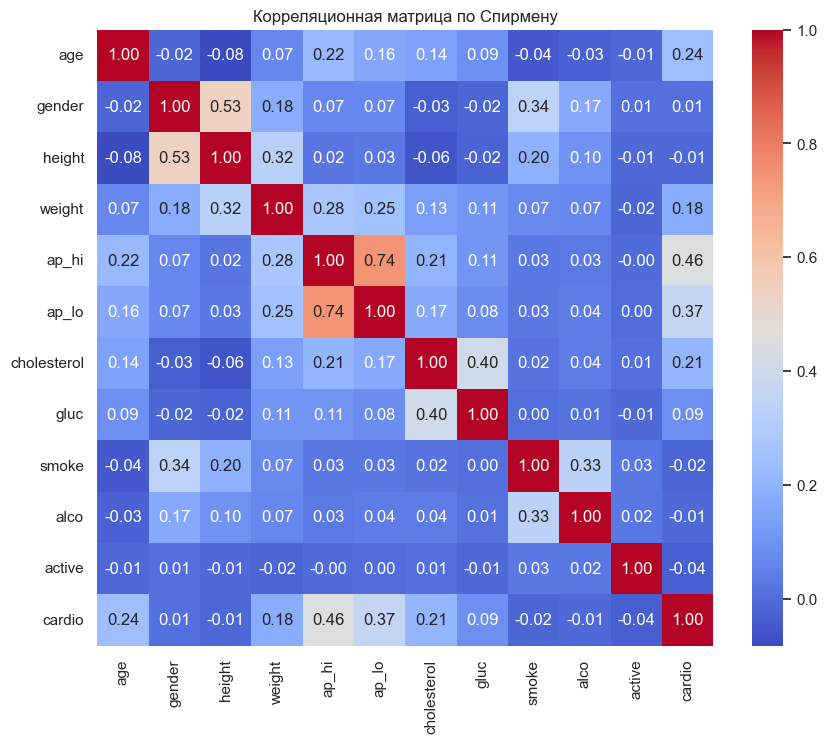

In [213]:
# Расчет корреляционной матрицы Спирмена
spearman_corr = df_train.corr(method='spearman')

# Визуализация корреляционной матрицы с использованием Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Корреляционная матрица по Спирмену')
plt.show()


     Variable 1   Variable 2  Cramer's V
0   cholesterol         gluc    0.389376
6          gluc  cholesterol    0.389376
20        smoke       gender    0.336943
14       gender        smoke    0.336943
27         alco        smoke    0.334834
21        smoke         alco    0.334834
5   cholesterol       cardio    0.219516
36       cardio  cholesterol    0.219516
26         alco       gender    0.168700
15       gender         alco    0.168700
37       cardio         gluc    0.088802
11         gluc       cardio    0.088802
3   cholesterol         alco    0.042916
24         alco  cholesterol    0.042916
35       active       cardio    0.034844
41       cardio       active    0.034844
12       gender  cholesterol    0.034003
1   cholesterol       gender    0.034003
22        smoke       active    0.029212
33       active        smoke    0.029212
2   cholesterol        smoke    0.028017
18        smoke  cholesterol    0.028017
25         alco         gluc    0.025678
9          gluc 

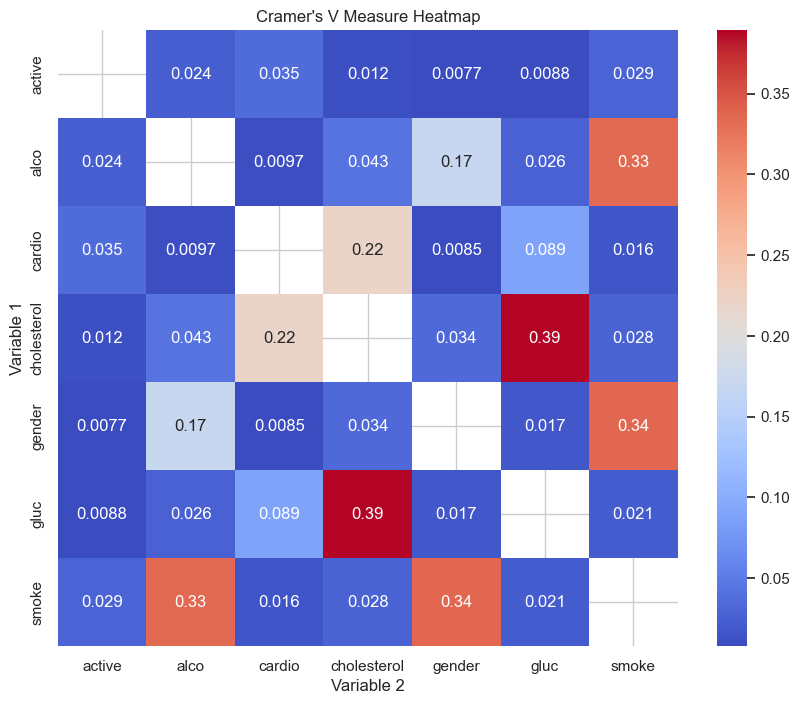

In [214]:
# Определение числовых и категориальных признаков
numeric_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active', 'cardio']

# Функция для расчета V-меры Крамера
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()  # Общее количество элементов в матрице
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Функция для создания матрицы частот и расчета V-меры Крамера
def calculate_cramers_v(df, col1, col2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])
    return cramers_v(confusion_matrix)

# Расчет V-меры Крамера для всех пар признаков
results = []
for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 != col2:
            v = calculate_cramers_v(df_train, col1, col2)
            results.append((col1, col2, v))

# Преобразование результатов в DataFrame
results_df = pd.DataFrame(results, columns=['Variable 1', 'Variable 2', 'Cramer\'s V'])
results_df = results_df.sort_values(by='Cramer\'s V', ascending=False)

# Вывод результатов
print(results_df)

# Создание сводной таблицы для тепловой карты
pivot_table = results_df.pivot_table(index='Variable 1', columns='Variable 2', values='Cramer\'s V')

# Визуализация V-меры Крамера
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title('Cramer\'s V Measure Heatmap')
plt.show()


In [215]:
anova_results = []
for cat_col in categorical_columns:
    for num_col in numeric_columns:
        f_val, p_val = stats.f_oneway(
            *[df_train[df_train[cat_col] == cat][num_col] for cat in df_train[cat_col].unique()]
        )
        anova_results.append((cat_col, num_col, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=['Categorical Variable', 'Numerical Variable', 'F-value', 'P-value'])
anova_df = anova_df.sort_values(by='P-value')

# Вывод результатов ANOVA
print(anova_df)


   Categorical Variable Numerical Variable       F-value        P-value
0           cholesterol                age   1292.849648   0.000000e+00
2           cholesterol             weight   1025.353050   0.000000e+00
3           cholesterol              ap_hi   1985.280409   0.000000e+00
4           cholesterol              ap_lo   1311.464250   0.000000e+00
12               gender             weight   2885.796063   0.000000e+00
11               gender             height  36895.504018   0.000000e+00
30               cardio                age   6244.028965   0.000000e+00
16                smoke             height   3907.461264   0.000000e+00
33               cardio              ap_hi  22643.683900   0.000000e+00
34               cardio              ap_lo  13208.871659   0.000000e+00
32               cardio             weight   3390.431220   0.000000e+00
7                  gluc             weight    722.109307  4.315212e-312
8                  gluc              ap_hi    510.839786  1.8655

In [216]:
# Дисперсия для числовых признаков
numeric_variance = df_train.var()

# Вывод результатов
print(numeric_variance)

age             45.839881
gender           0.227748
height          62.277873
weight         197.020281
ap_hi          291.985968
ap_lo           99.927139
cholesterol      0.462294
gluc             0.325520
smoke            0.080479
alco             0.051209
active           0.157385
cardio           0.250003
dtype: float64


In [217]:
# Медиана для числовых признаков
numeric_median = df_train.median()

# Мода для числовых признаков
numeric_mode = df_train.mode().iloc[0]

# Вывод результатов
print("Медиана:\n", numeric_median)
print("\nМода:\n", numeric_mode)

Медиана:
 age             53.0
gender           1.0
height         165.0
weight          72.0
ap_hi          120.0
ap_lo           80.0
cholesterol      1.0
gluc             1.0
smoke            0.0
alco             0.0
active           1.0
cardio           0.5
dtype: float64

Мода:
 age             55.0
gender           1.0
height         165.0
weight          65.0
ap_hi          120.0
ap_lo           80.0
cholesterol      1.0
gluc             1.0
smoke            0.0
alco             0.0
active           1.0
cardio           0.0
Name: 0, dtype: float64


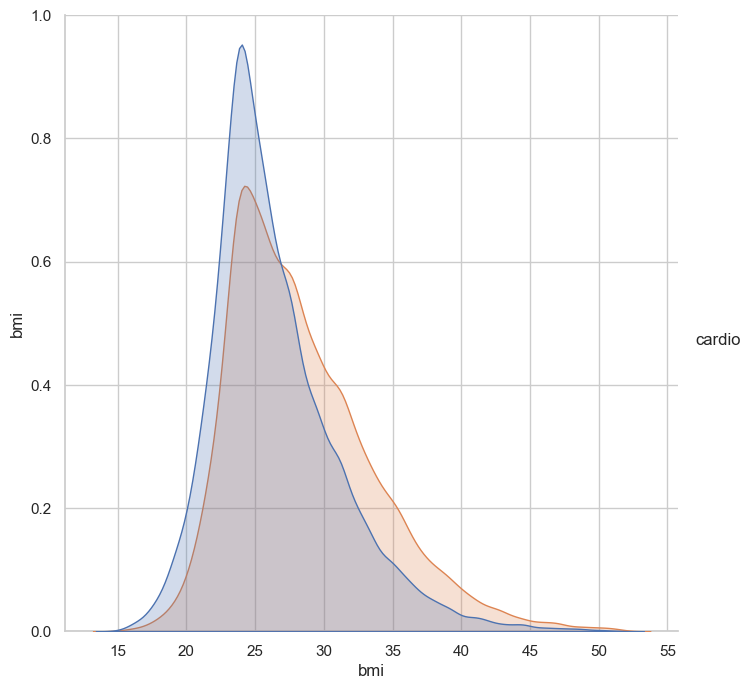

In [218]:
df_train['bmi'] = df_train['weight'] / (df_train['height'] * df_train['height'] / 10000)

sns.pairplot(df_train[['bmi', 'cardio']],  hue='cardio', height=7);

Из графика видно что индекс массы тела практически не дает разделения выборки по таргету cardio.

Расчитаем среднее артериальное давление.

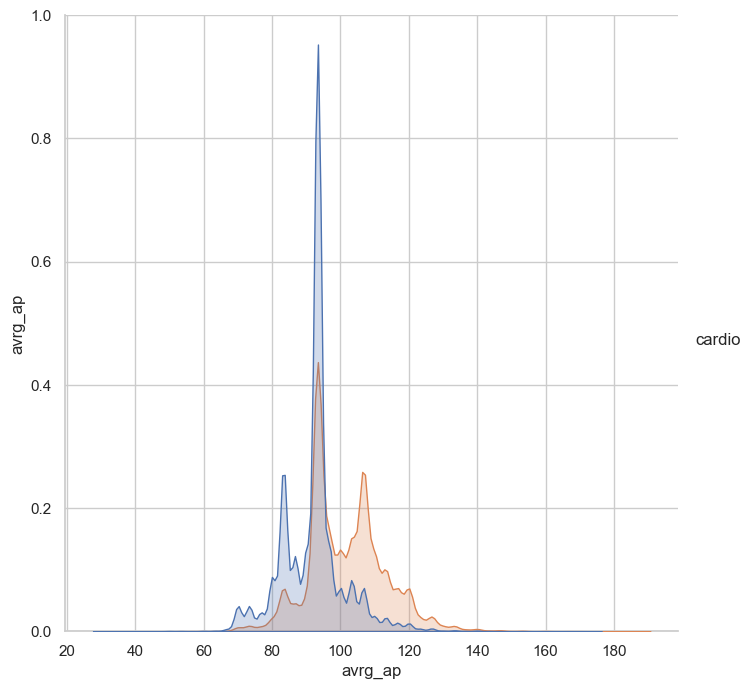

In [219]:
df_train['avrg_ap'] = np.round((2 * df_train['ap_lo'] + df_train['ap_hi']) / 3, 1)

_ = sns.pairplot(df_train[['avrg_ap', 'cardio']], hue='cardio', height=7)

Из графика видно, что новый признак достаточно разделяет выборки по таргету.

Подсчитаем как наличие холестерина, сахара с учетом артериального давления и возраста может повлиять на риск возникновения ССЗ.

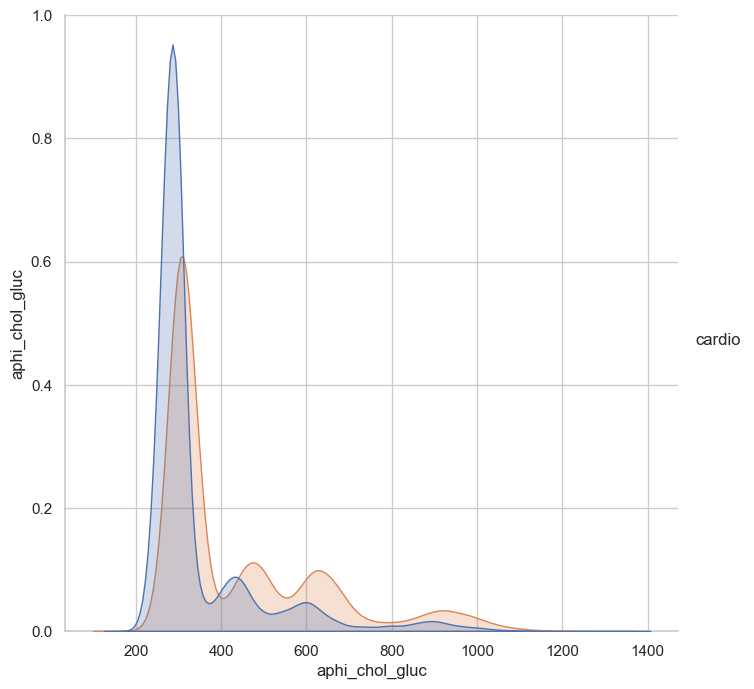

In [220]:
df_train['aphi_chol_gluc'] = (df_train['avrg_ap'] + df_train['age']) * (df_train['cholesterol'] + df_train['gluc'])

_ = sns.pairplot(df_train[['aphi_chol_gluc', 'cardio']],  hue='cardio', height=7);

Расчитаем риск ССЗ с учетом возраста, среднего артериального давления и показатедя aphi_chol_gluc.

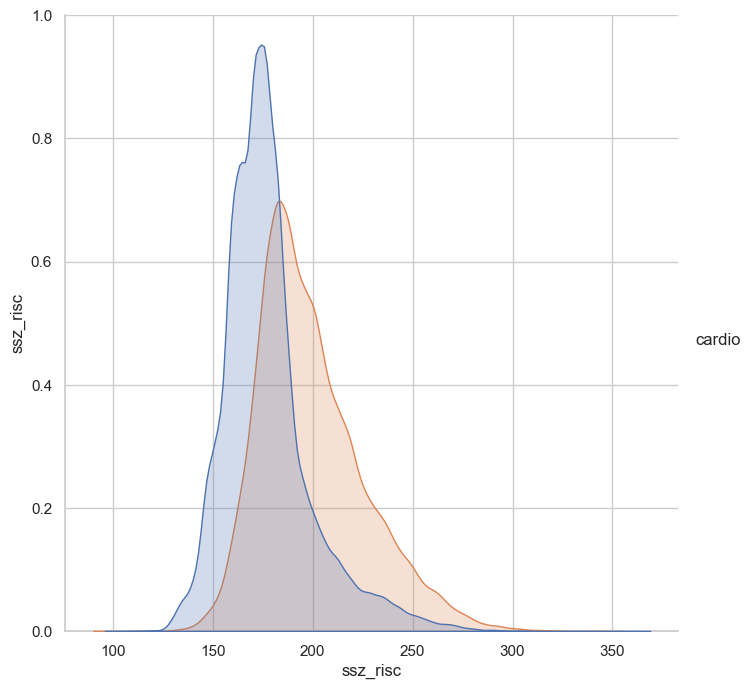

In [221]:
df_train['ssz_risc'] = (df_train['age'] + df_train['avrg_ap'] + df_train['aphi_chol_gluc'] // 10)

_ = sns.pairplot(df_train[['ssz_risc', 'cardio']], hue='cardio', height=7);

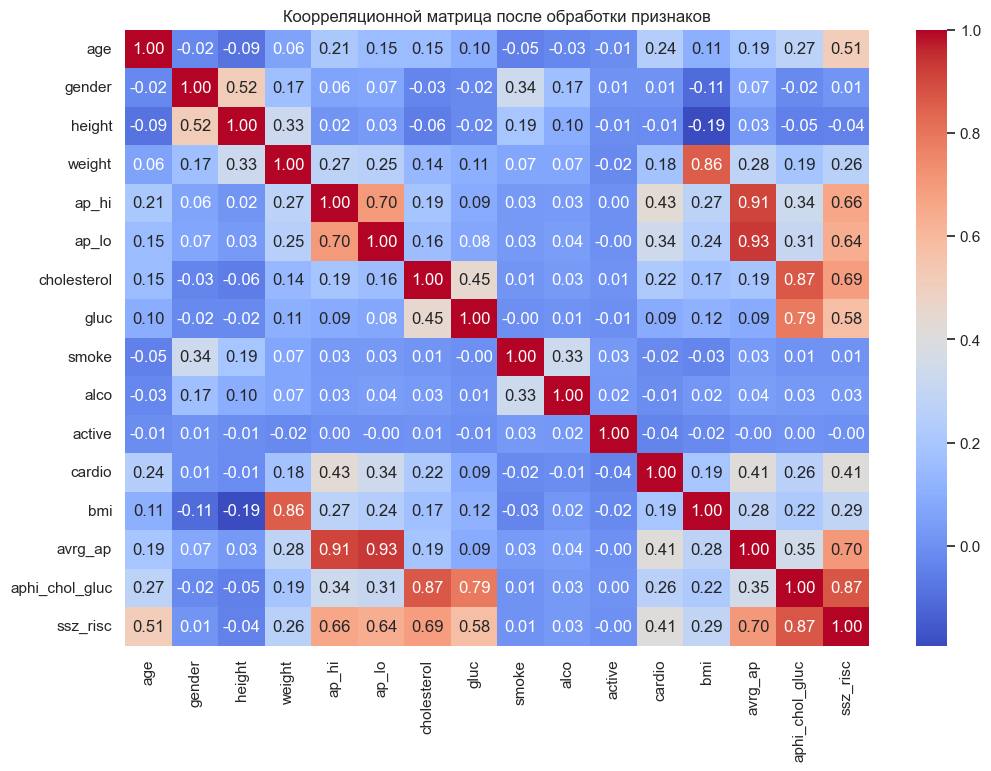

In [222]:
# Построение корреляционной матрицы
correlation_matrix = df_train.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Кoорреляционной матрица после обработки признаков")
plt.show()

# Извлечение лучших параметров и метрик для AHP

In [223]:
def objective(trial):
    # Разделение данных
    X = df_train.drop('cardio', axis=1)
    y = df_train['cardio']
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Выбираем критерии (признаки) для AHP
    criteria = ['age', 'ap_hi', 'ap_lo', 'weight', 'height', 'cholesterol', 'gluc']
    # Для простоты возьмём только числовые (хотя категориальные тоже можно включить после кодирования)
    
    # В AHP мы должны задать матрицу попарных сравнений для критериев.
    # Вместо этого мы будем использовать веса, которые Optuna подбирает напрямую.
    # Но для использования AHP нам нужно сгенерировать матрицу сравнений из весов.
    # Простой способ: создать матрицу, где элемент (i,j) = weight_i / weight_j.
    # Тогда собственный вектор даст исходные веса.
    
    # Подбираем веса критериев
    weights = {}
    for c in criteria:
        weights[c] = trial.suggest_float(f'weight_{c}', 0.01, 1.0)
    
    # Нормализуем, чтобы сумма была 1 (хотя ahpy это делает сама)
    total = sum(weights.values())
    for c in criteria:
        weights[c] /= total
    
    # Создаём матрицу попарных сравнений на основе весов
    comparisons = {}
    for i, ci in enumerate(criteria):
        for j, cj in enumerate(criteria):
            if i < j:
                # Отношение важности ci к cj
                ratio = weights[ci] / weights[cj]
                comparisons[(ci, cj)] = ratio
    
    # Создаём объект AHP
    ahp_model = ahpy.Compare(name='HealthRisk', comparisons=comparisons, precision=3, random_index='saaty')
    
    # Получаем веса (они должны совпадать с исходными, но небольшие отличия возможны)
    final_weights = ahp_model.target_weights
    
    # Вычисляем приоритеты для каждого пациента как взвешенную сумму (или произведение)
    # Предварительно нормализуем признаки
    X_train_norm = (X_train[criteria] - X_train[criteria].min()) / (X_train[criteria].max() - X_train[criteria].min())
    X_valid_norm = (X_valid[criteria] - X_train[criteria].min()) / (X_train[criteria].max() - X_train[criteria].min())

    directions = {
        'age': 1,           # возраст: чем больше, тем выше риск
        'ap_hi': 1,         # систолическое давление: чем больше, тем выше риск
        'ap_lo': 1,         # диастолическое давление: чем больше, тем выше риск
        'weight': 1,        # вес: чем больше, тем выше риск
        'height': -1,       # рост: чем больше, тем ниже риск (если ИМТ постоянен)
        'cholesterol': 1,
        'gluc': 1
    }
    
    # Приоритеты = взвешенная сумма (чем выше, тем больше риск)
    priorities_train = np.dot(
        X_train_norm.fillna(0) * [directions[c] for c in criteria],
        [final_weights[c] for c in criteria]   # если final_weights — словарь
    )
    priorities_valid = np.dot(
        X_valid_norm.fillna(0) * [directions[c] for c in criteria],
        [final_weights[c] for c in criteria]
    )
    # Преобразуем приоритеты в вероятности (можно использовать сигмоиду или просто нормализацию)
    # Для бинарной классификации можно использовать порог
    proba = (priorities_valid - priorities_valid.min()) / (priorities_valid.max() - priorities_valid.min())
    
    # Метрики
    roc_auc = roc_auc_score(y_valid, proba)
    # Для accuracy и f1 нужны бинарные предсказания - порог можно оптимизировать или использовать 0.5
    preds = (proba > 0.5).astype(int)
    accuracy = accuracy_score(y_valid, preds)
    f1 = f1_score(y_valid, preds)
    
    # Сохраняем
    precision = precision_score(y_valid, preds)
    logloss = log_loss(y_valid, proba)

    trial.set_user_attr('Precision', precision)
    trial.set_user_attr('Log Loss', logloss)
    trial.set_user_attr('Accuracy', accuracy)
    trial.set_user_attr('ROC AUC', roc_auc)
    trial.set_user_attr('F1 Score', f1)
    
    return -roc_auc  # максимизируем ROC AUC

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best trial:")
print(f"Value (ROC AUC): {best_trial.value}")
print("Best weights:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")
print("\nAdditional metrics:")
for key, value in best_trial.user_attrs.items():
    print(f"  {key}: {value}")

[I 2026-03-12 03:18:26,403] A new study created in memory with name: no-name-0de9e721-ab64-4dfb-abc1-4aa2baa56ee2


[I 2026-03-12 03:18:26,472] Trial 0 finished with value: -0.7257431743366364 and parameters: {'weight_age': 0.8773217874497597, 'weight_ap_hi': 0.8098230119749645, 'weight_ap_lo': 0.30748932924691275, 'weight_weight': 0.7105581578513086, 'weight_height': 0.4519477706120048, 'weight_cholesterol': 0.3061973476712809, 'weight_gluc': 0.9712768133324913}. Best is trial 0 with value: -0.7257431743366364.
[I 2026-03-12 03:18:26,529] Trial 1 finished with value: -0.7187696254167538 and parameters: {'weight_age': 0.9290444903340651, 'weight_ap_hi': 0.6370572493578969, 'weight_ap_lo': 0.19933752682229763, 'weight_weight': 0.3677556048446117, 'weight_height': 0.7511393210004899, 'weight_cholesterol': 0.5189037783117545, 'weight_gluc': 0.43807656163094966}. Best is trial 1 with value: -0.7187696254167538.
[I 2026-03-12 03:18:26,593] Trial 2 finished with value: -0.7390331588401474 and parameters: {'weight_age': 0.08181894763497705, 'weight_ap_hi': 0.9705581707850328, 'weight_ap_lo': 0.484918873819

Best trial:
Value (ROC AUC): -0.6438463828615395
Best weights:
  weight_age: 0.873058565809347
  weight_ap_hi: 0.0726225036752953
  weight_ap_lo: 0.018625745527706086
  weight_weight: 0.057353944938015496
  weight_height: 0.8366526737858406
  weight_cholesterol: 0.01375443042202884
  weight_gluc: 0.5233776898562426

Additional metrics:
  Precision: 0.6423365157581357
  Log Loss: 0.67331572025179
  Accuracy: 0.5924
  ROC AUC: 0.6438463828615395
  F1 Score: 0.5057796459461644


# Визуализация истории оптимизации для AHP

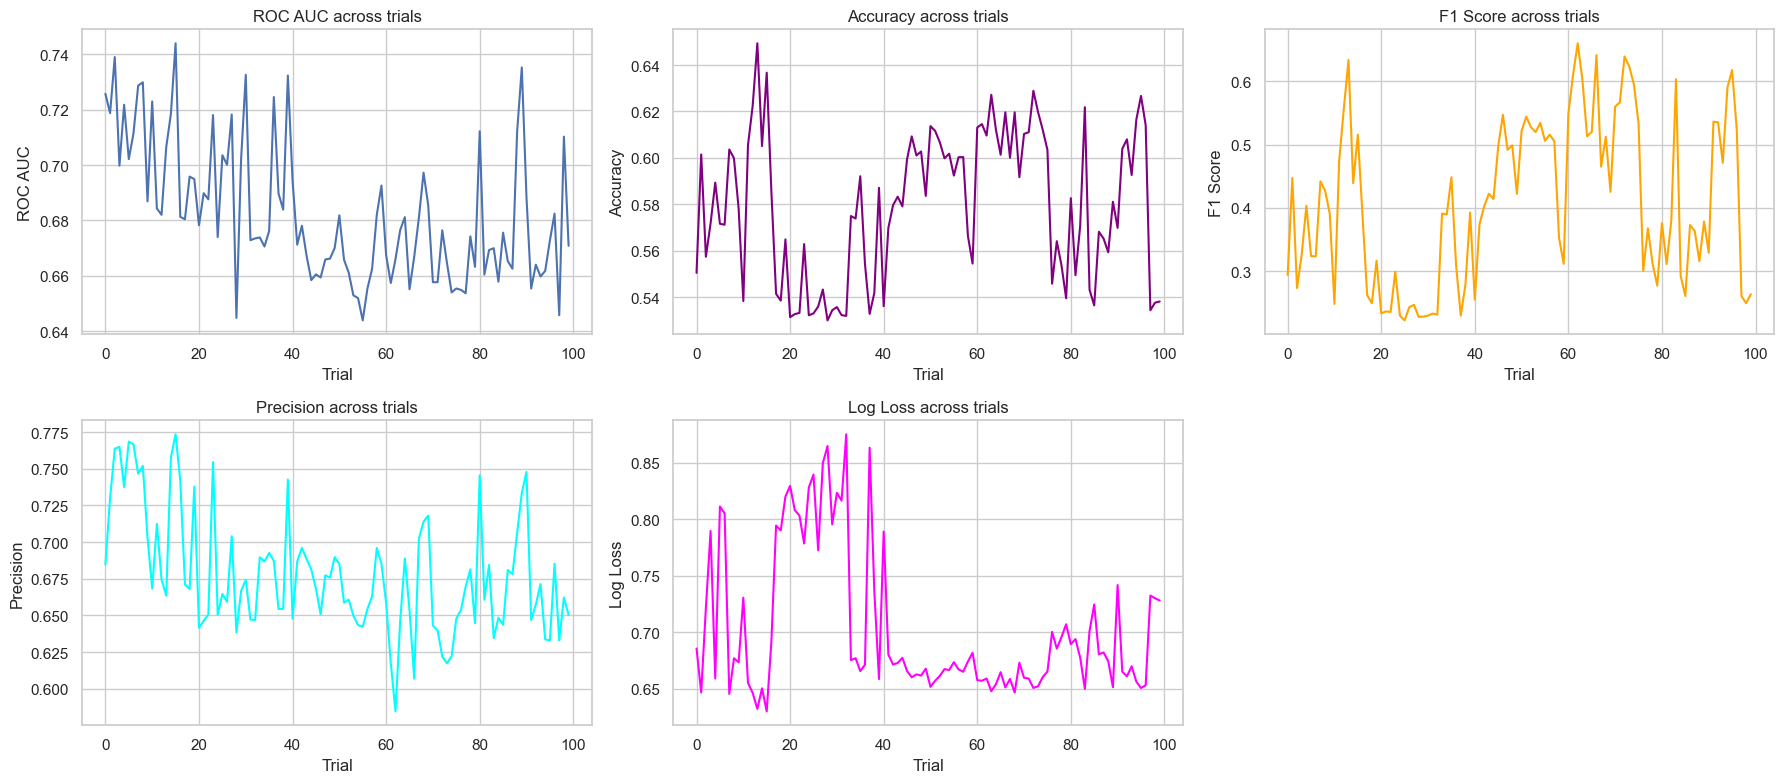

In [224]:
# Извлечение метрик из всех trials
roc_aucs = [-t.value for t in study.trials]  # так как мы максимизировали -roc_auc, то настоящий roc_auc = -value
accuracies = [t.user_attrs['Accuracy'] for t in study.trials if 'Accuracy' in t.user_attrs]
f1_scores = [t.user_attrs['F1 Score'] for t in study.trials if 'F1 Score' in t.user_attrs]
precisions = [t.user_attrs['Precision'] for t in study.trials if 'Precision' in t.user_attrs]
log_losses = [t.user_attrs['Log Loss'] for t in study.trials if 'Log Loss' in t.user_attrs]

# Создаем сетку 2x3 (6 графиков, но используем только 5)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()  # чтобы обращаться по индексу

# График 1: ROC AUC
axes[0].plot(roc_aucs)
axes[0].set_title('ROC AUC across trials')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('ROC AUC')

# График 2: Accuracy
axes[1].plot(accuracies, color='purple')
axes[1].set_title('Accuracy across trials')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Accuracy')

# График 3: F1 Score
axes[2].plot(f1_scores, color='orange')
axes[2].set_title('F1 Score across trials')
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('F1 Score')

# График 4: Precision
axes[3].plot(precisions, color='cyan')
axes[3].set_title('Precision across trials')
axes[3].set_xlabel('Trial')
axes[3].set_ylabel('Precision')

# График 5: Log Loss
axes[4].plot(log_losses, color='magenta')
axes[4].set_title('Log Loss across trials')
axes[4].set_xlabel('Trial')
axes[4].set_ylabel('Log Loss')

# График 6: пустой (скрываем)
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Оценка важности критериев для AHP

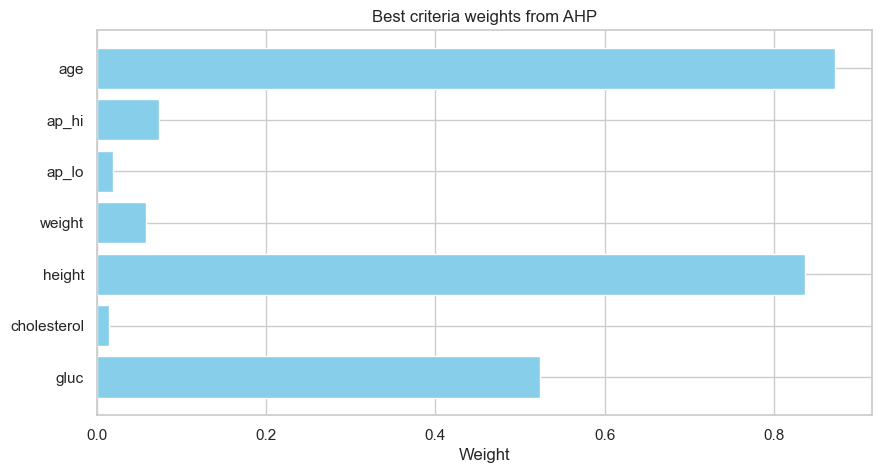

In [225]:
best_weights = {k: v for k, v in best_trial.params.items() if k.startswith('weight_')}
criteria_names = [k.replace('weight_', '') for k in best_weights.keys()]
weight_values = list(best_weights.values())

plt.figure(figsize=(10, 5))
plt.barh(criteria_names, weight_values, color='skyblue')
plt.xlabel('Weight')
plt.title('Best criteria weights from AHP')
plt.gca().invert_yaxis()
plt.show()

# Применение лучших весов на тестовой выборке для AHP

In [226]:
# Выбор критериев
criteria = ['age', 'ap_hi', 'ap_lo', 'weight', 'height', 'cholesterol', 'gluc']

# Разделите данные на train/test (можно использовать то же разбиение, что и в objective)
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Нормализуйте тестовые данные, используя min/max из обучающей выборки (как в objective)
X_train_norm = (X_train[criteria] - X_train[criteria].min()) / (X_train[criteria].max() - X_train[criteria].min())
X_test_norm = (X_test[criteria] - X_train[criteria].min()) / (X_train[criteria].max() - X_train[criteria].min())

# Вычислите приоритеты
priorities_test = np.dot(X_test_norm.fillna(0), [best_weights[f'weight_{c}'] for c in criteria])

# Преобразуйте в вероятности (как в objective)
proba_test = (priorities_test - priorities_test.min()) / (priorities_test.max() - priorities_test.min())

# Метрики
roc_auc_test = roc_auc_score(y_test, proba_test)
print(f"ROC AUC on test: {roc_auc_test:.4f}")

# Пороговое предсказание (можно оптимизировать порог или использовать 0.5)
preds_test = (proba_test > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, preds_test):.4f}")
print(f"F1: {f1_score(y_test, preds_test):.4f}")

precision_test = precision_score(y_test, preds_test)
logloss_test = log_loss(y_test, proba_test)
print(f"Precision: {precision_test:.4f}")
print(f"Log Loss: {logloss_test:.4f}")

ROC AUC on test: 0.6473
Accuracy: 0.5908
F1: 0.5014
Precision: 0.6416
Log Loss: 0.6696


# Сохраняем модель для AHP

In [227]:
with open('best_ahp_weights.pkl', 'wb') as f:
    pickle.dump(best_weights, f)

# Функция objective для TOPSIS

In [228]:
def objective(trial):
    # Разделение данных
    X = df_train.drop('cardio', axis=1)
    y = df_train['cardio']
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Критерии и их направления (+1 – максимизировать, -1 – минимизировать)
    criteria = ['age', 'ap_hi', 'ap_lo', 'weight', 'height', 'cholesterol', 'gluc']
    directions = {
        'age': 1,          # чем больше, тем выше риск → максимизируем
        'ap_hi': 1,
        'ap_lo': 1,
        'weight': 1,
        'height': -1,      # чем больше рост, тем ниже риск → минимизируем
        'cholesterol': 1,
        'gluc': 1
    }
    dir_list = [directions[c] for c in criteria]
    
    # Подбор весов критериев (нормализуем позже)
    weights_raw = [trial.suggest_float(f'weight_{c}', 0.01, 1.0) for c in criteria]
    weights = np.array(weights_raw) / np.sum(weights_raw)
    
    # Нормализация данных (min-max)
    mins = X_train[criteria].min()
    maxs = X_train[criteria].max()
    ranges = maxs - mins
    ranges[ranges == 0] = 1  # защита от деления на ноль
    
    X_train_norm = (X_train[criteria] - mins) / ranges
    X_valid_norm = (X_valid[criteria] - mins) / ranges
    X_train_norm = X_train_norm.fillna(0).values
    X_valid_norm = X_valid_norm.fillna(0).values
    
    # --- TOPSIS ---
    # 1. Взвешенная нормализованная матрица (нормализация по вектору)
    # Сначала нормализуем каждый столбец по вектору (деление на корень из суммы квадратов)
    norm_train = X_train_norm / np.sqrt(np.sum(X_train_norm**2, axis=0))
    norm_valid = X_valid_norm / np.sqrt(np.sum(X_train_norm**2, axis=0))  # используем нормы train
    
    # Умножаем на веса
    weighted_train = norm_train * weights
    weighted_valid = norm_valid * weights
    
    # 2. Идеальное положительное (PIS) и отрицательное (NIS) решения
    # Для максимизируемых критериев (dir=1): PIS = max, NIS = min
    # Для минимизируемых (dir=-1): PIS = min, NIS = max
    pis = []
    nis = []
    for j, d in enumerate(dir_list):
        if d == 1:  # максимизируем
            pis.append(np.max(weighted_train[:, j]))
            nis.append(np.min(weighted_train[:, j]))
        else:       # минимизируем
            pis.append(np.min(weighted_train[:, j]))
            nis.append(np.max(weighted_train[:, j]))
    pis = np.array(pis)
    nis = np.array(nis)
    
    # 3. Расстояния до PIS и NIS для валидационной выборки
    dist_pis = np.sqrt(np.sum((weighted_valid - pis)**2, axis=1))
    dist_nis = np.sqrt(np.sum((weighted_valid - nis)**2, axis=1))
    
    # 4. Коэффициент близости (closeness) – чем ближе к 1, тем лучше
    closeness = dist_nis / (dist_pis + dist_nis + 1e-12)  # защита от деления на ноль
    
    # Используем closeness как вероятность (уже в [0,1])
    proba = closeness
    
    # Метрики
    roc_auc = roc_auc_score(y_valid, proba)
    preds = (proba > 0.5).astype(int)
    accuracy = accuracy_score(y_valid, preds)
    f1 = f1_score(y_valid, preds)
    precision = precision_score(y_valid, preds)
    logloss = log_loss(y_valid, proba)
    
    # Сохраняем
    trial.set_user_attr('Accuracy', accuracy)
    trial.set_user_attr('ROC AUC', roc_auc)
    trial.set_user_attr('F1 Score', f1)
    trial.set_user_attr('Precision', precision)
    trial.set_user_attr('Log Loss', logloss)
    
    return -roc_auc  # для совместимости с примером (study.maximize)

# Запуск оптимизации и визуализация

[I 2026-03-12 03:18:33,922] A new study created in memory with name: no-name-1ce4da0c-5f63-4c32-b5a7-8182be9fb143
[I 2026-03-12 03:18:33,991] Trial 0 finished with value: -0.6974771897665653 and parameters: {'weight_age': 0.5909165582387058, 'weight_ap_hi': 0.0765667184481828, 'weight_ap_lo': 0.9560598246497365, 'weight_weight': 0.9706187507873015, 'weight_height': 0.32388582409711547, 'weight_cholesterol': 0.6581486836768071, 'weight_gluc': 0.615860528285017}. Best is trial 0 with value: -0.6974771897665653.
[I 2026-03-12 03:18:34,047] Trial 1 finished with value: -0.7381682432807477 and parameters: {'weight_age': 0.415686043026584, 'weight_ap_hi': 0.4080859886331695, 'weight_ap_lo': 0.920934616359941, 'weight_weight': 0.6705536912880725, 'weight_height': 0.3716861281873905, 'weight_cholesterol': 0.5440398278587499, 'weight_gluc': 0.16264637585958855}. Best is trial 0 with value: -0.6974771897665653.
[I 2026-03-12 03:18:34,106] Trial 2 finished with value: -0.7034674920154111 and para

Best trial:
Value (ROC AUC): -0.5497772468878989
Best weights:
  weight_age: 0.014053064473743191
  weight_ap_hi: 0.09722962860141693
  weight_ap_lo: 0.23021594814340274
  weight_weight: 0.010020736226951729
  weight_height: 0.9773351539918397
  weight_cholesterol: 0.010689981225138326
  weight_gluc: 0.18277417068336235

Additional metrics:
  Accuracy: 0.5128333333333334
  ROC AUC: 0.5497772468878989
  F1 Score: 0.08364160762430246
  Precision: 0.7035864978902954
  Log Loss: 0.7209371925719786


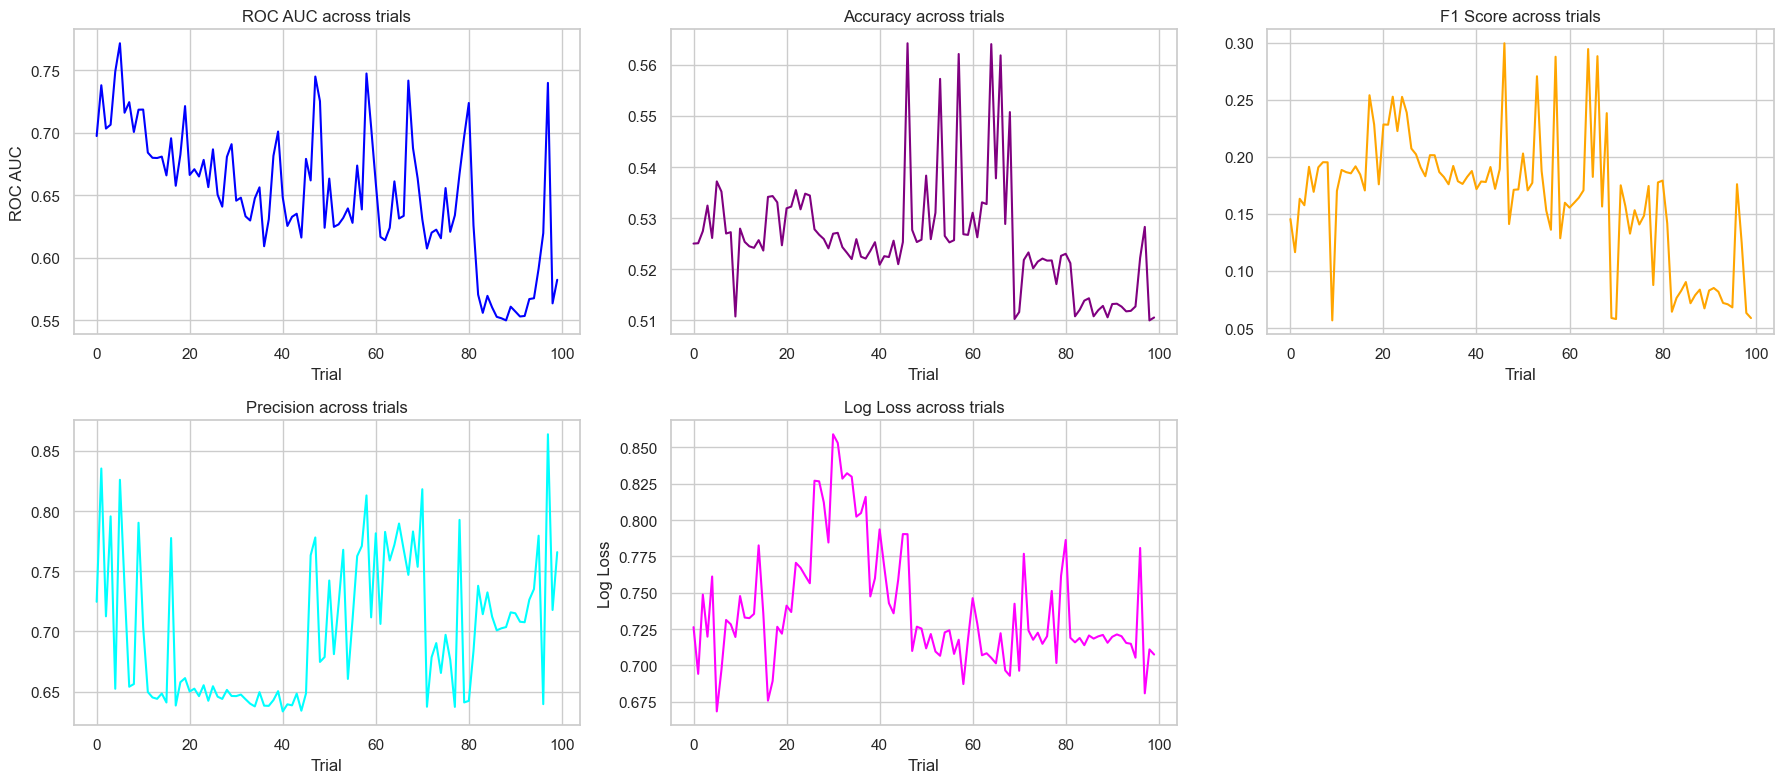

In [229]:
# Создание и оптимизация исследования
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Лучший триал
best_trial = study.best_trial
print("Best trial:")
print(f"Value (ROC AUC): {best_trial.value}")
print("Best weights:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")
print("\nAdditional metrics:")
for key, value in best_trial.user_attrs.items():
    print(f"  {key}: {value}")

# Извлечение метрик из всех trials
roc_aucs = [-t.value for t in study.trials]  # т.к. мы сохраняли -roc_auc
accuracies = [t.user_attrs['Accuracy'] for t in study.trials]
f1_scores = [t.user_attrs['F1 Score'] for t in study.trials]
precisions = [t.user_attrs['Precision'] for t in study.trials]
log_losses = [t.user_attrs['Log Loss'] for t in study.trials]

# Сетка графиков 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

axes[0].plot(roc_aucs, color='blue')
axes[0].set_title('ROC AUC across trials')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('ROC AUC')

axes[1].plot(accuracies, color='purple')
axes[1].set_title('Accuracy across trials')
axes[1].set_xlabel('Trial')

axes[2].plot(f1_scores, color='orange')
axes[2].set_title('F1 Score across trials')
axes[2].set_xlabel('Trial')

axes[3].plot(precisions, color='cyan')
axes[3].set_title('Precision across trials')
axes[3].set_xlabel('Trial')

axes[4].plot(log_losses, color='magenta')
axes[4].set_title('Log Loss across trials')
axes[4].set_xlabel('Trial')
axes[4].set_ylabel('Log Loss')

axes[5].axis('off')
plt.tight_layout()
plt.show()

# Финальное тестирование на тестовой выборке


ROC AUC on test: 0.5498
Accuracy: 0.5128
F1: 0.0836
Precision: 0.7036
Log Loss: 0.7209


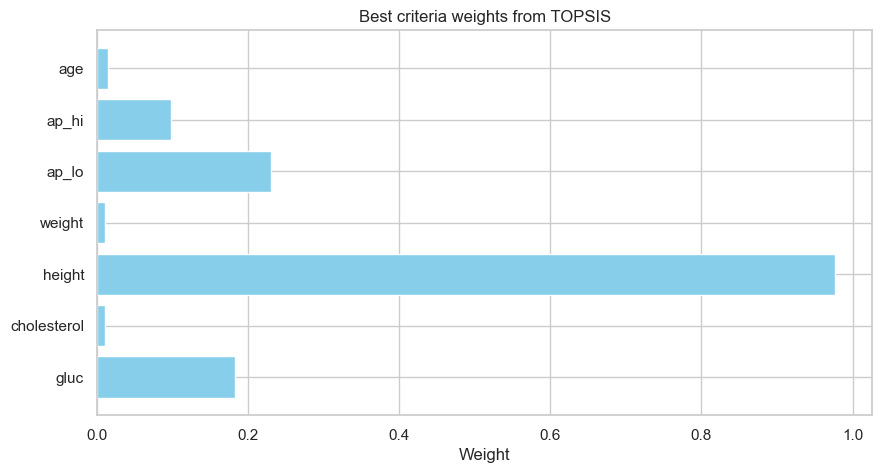

In [230]:
# Подготовка тестовых данных (с использованием параметров train)
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Критерии и направления (те же, что использовались в objective)
criteria = ['age', 'ap_hi', 'ap_lo', 'weight', 'height', 'cholesterol', 'gluc']
dir_list = [1, 1, 1, 1, -1, 1, 1]  # +1 – максимизировать, -1 – минимизировать

# Нормализация min-max (на основе обучающей выборки)
mins = X_train[criteria].min()
maxs = X_train[criteria].max()
ranges = maxs - mins
ranges[ranges == 0] = 1  # защита от константных признаков

X_train_norm = (X_train[criteria] - mins) / ranges
X_test_norm = (X_test[criteria] - mins) / ranges
X_train_norm = X_train_norm.fillna(0).values
X_test_norm = X_test_norm.fillna(0).values

# Векторная нормализация (деление на корень из суммы квадратов по столбцам обучающей выборки)
norm_factors = np.sqrt(np.sum(X_train_norm**2, axis=0))
norm_factors[norm_factors == 0] = 1  # защита от нулевых норм

X_train_normed = X_train_norm / norm_factors
X_test_normed = X_test_norm / norm_factors

# Лучшие веса из триала
best_weights = [best_trial.params[f'weight_{c}'] for c in criteria]
best_weights = np.array(best_weights) / np.sum(best_weights)  # нормализация

# Взвешенные матрицы
weighted_train = X_train_normed * best_weights
weighted_test = X_test_normed * best_weights

# Идеальное положительное (PIS) и отрицательное (NIS) решения на обучающей выборке
pis = []
nis = []
for j, d in enumerate(dir_list):
    if d == 1:  # максимизируемый критерий
        pis.append(np.max(weighted_train[:, j]))
        nis.append(np.min(weighted_train[:, j]))
    else:       # минимизируемый критерий
        pis.append(np.min(weighted_train[:, j]))
        nis.append(np.max(weighted_train[:, j]))
pis = np.array(pis)
nis = np.array(nis)

# Расстояния до идеальных решений на тесте
dist_pis = np.sqrt(np.sum((weighted_test - pis)**2, axis=1))
dist_nis = np.sqrt(np.sum((weighted_test - nis)**2, axis=1))

# Коэффициент близости (чем ближе к 1, тем лучше)
closeness = dist_nis / (dist_pis + dist_nis + 1e-12)

# Используем closeness как вероятность
proba_test = closeness

# Метрики
roc_auc_test = roc_auc_score(y_test, proba_test)
print(f"\nROC AUC on test: {roc_auc_test:.4f}")

preds_test = (proba_test > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, preds_test):.4f}")
print(f"F1: {f1_score(y_test, preds_test):.4f}")
print(f"Precision: {precision_score(y_test, preds_test):.4f}")
print(f"Log Loss: {log_loss(y_test, proba_test):.4f}")

# Визуализация весов лучшего триала
best_weights_dict = {k: v for k, v in best_trial.params.items() if k.startswith('weight_')}
criteria_names = [k.replace('weight_', '') for k in best_weights_dict.keys()]
weight_values = list(best_weights_dict.values())

plt.figure(figsize=(10, 5))
plt.barh(criteria_names, weight_values, color='skyblue')
plt.xlabel('Weight')
plt.title('Best criteria weights from TOPSIS')
plt.gca().invert_yaxis()
plt.show()

# Сохраняем модель для TOPSIS

In [231]:
with open('topsis_weights.pkl', 'wb') as f:
    pickle.dump(best_trial.params, f)

# Сравнение TOPSIS и AHP

Функции для расчета метрик TOPSIS по весам (аналогично финальному тестированию) и аналогично для AHP

In [232]:
def topsis_predict(weights_dict, X_train, X_test, y_test, criteria, dir_list):
    # Извлечение весов
    weights = [weights_dict[f'weight_{c}'] for c in criteria]
    weights = np.array(weights) / np.sum(weights)
    
    # Нормализация
    mins = X_train[criteria].min()
    maxs = X_train[criteria].max()
    ranges = maxs - mins
    ranges[ranges == 0] = 1
    X_train_norm = (X_train[criteria] - mins) / ranges
    X_test_norm = (X_test[criteria] - mins) / ranges
    X_train_norm = X_train_norm.fillna(0).values
    X_test_norm = X_test_norm.fillna(0).values
    
    norm_factors = np.sqrt(np.sum(X_train_norm**2, axis=0))
    norm_factors[norm_factors == 0] = 1
    X_train_normed = X_train_norm / norm_factors
    X_test_normed = X_test_norm / norm_factors
    
    weighted_train = X_train_normed * weights
    weighted_test = X_test_normed * weights
    
    pis, nis = [], []
    for j, d in enumerate(dir_list):
        if d == 1:
            pis.append(np.max(weighted_train[:, j]))
            nis.append(np.min(weighted_train[:, j]))
        else:
            pis.append(np.min(weighted_train[:, j]))
            nis.append(np.max(weighted_train[:, j]))
    pis = np.array(pis)
    nis = np.array(nis)
    
    dist_pis = np.sqrt(np.sum((weighted_test - pis)**2, axis=1))
    dist_nis = np.sqrt(np.sum((weighted_test - nis)**2, axis=1))
    closeness = dist_nis / (dist_pis + dist_nis + 1e-12)
    
    return closeness

def ahp_predict(weights_dict, X_train, X_test, y_test, criteria, directions):
    weights = [weights_dict[f'weight_{c}'] for c in criteria]
    weights = np.array(weights) / np.sum(weights)
    
    mins = X_train[criteria].min()
    maxs = X_train[criteria].max()
    ranges = maxs - mins
    ranges[ranges == 0] = 1
    X_test_norm = (X_test[criteria] - mins) / ranges
    X_test_norm = X_test_norm.fillna(0).values
    
    # Для AHP использовалась взвешенная сумма с направлениями
    dir_vec = np.array([directions[c] for c in criteria])
    priorities = np.dot(X_test_norm * dir_vec, weights)
    # Нормализация в [0,1] как в objective
    proba = (priorities - priorities.min()) / (priorities.max() - priorities.min() + 1e-12)
    return proba

Сравнение TOPSIS и AHP:
        ROC AUC  Accuracy      F1  Precision  Recall  Log Loss
TOPSIS   0.5498    0.5128  0.0836     0.7036  0.0445    0.7209
AHP      0.5919    0.5598  0.3849     0.6387  0.2754    0.6970


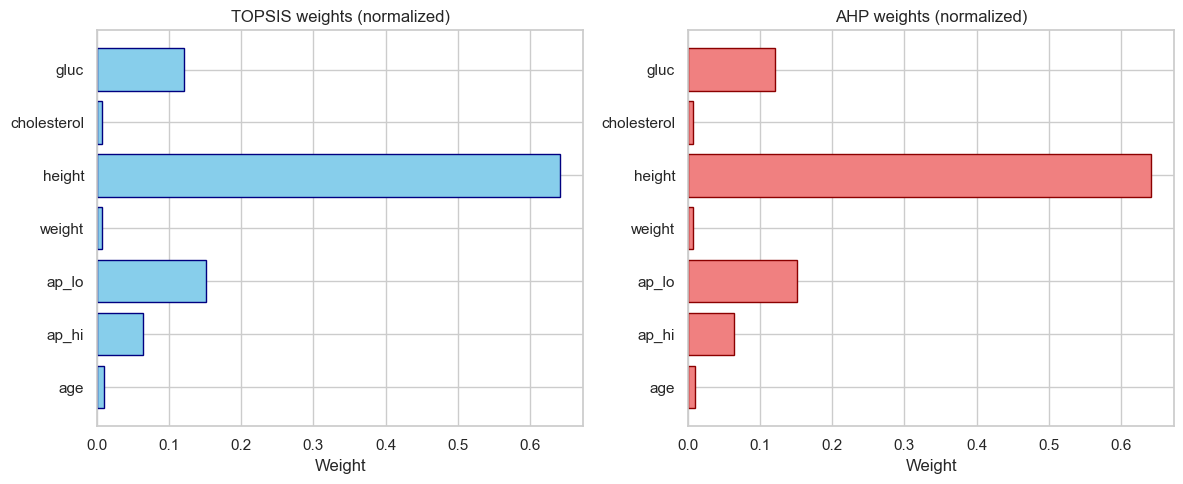

In [238]:
# Подготовка данных
criteria = ['age', 'ap_hi', 'ap_lo', 'weight', 'height', 'cholesterol', 'gluc']
dir_list = [1, 1, 1, 1, -1, 1, 1]          # для TOPSIS
directions_ahp = {                         # для AHP
    'age': 1, 'ap_hi': 1, 'ap_lo': 1, 'weight': 1,
    'height': -1, 'cholesterol': 1, 'gluc': 1
}

X = df_train.drop('cardio', axis=1)
y = df_train['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

best_weights = {k: v for k, v in best_trial.params.items() if k.startswith('weight_')}

# Получение вероятностей от каждой модели
# Для TOPSIS используем best_trial.params (словарь из Optuna)
proba_topsis = topsis_predict(best_trial.params, X_train, X_test, y_test, criteria, dir_list)
# Для AHP используем ранее полученный словарь best_weights (веса из лучшего триала AHP)
proba_ahp = ahp_predict(best_weights, X_train, X_test, y_test, criteria, directions_ahp)

# Функция для расчета метрик
def calc_metrics(y_true, proba):
    pred = (proba > 0.5).astype(int)
    return {
        'ROC AUC': roc_auc_score(y_true, proba),
        'Accuracy': accuracy_score(y_true, pred),
        'F1': f1_score(y_true, pred),
        'Precision': precision_score(y_true, pred),
        'Recall': recall_score(y_true, pred),
        'Log Loss': log_loss(y_true, proba)
    }

metrics_topsis = calc_metrics(y_test, proba_topsis)
metrics_ahp = calc_metrics(y_test, proba_ahp)

# Сравнительная таблица
comparison_df = pd.DataFrame({
    'TOPSIS': metrics_topsis,
    'AHP': metrics_ahp
}).T

print("Сравнение TOPSIS и AHP:")
print(comparison_df.round(4))

# Визуализация весов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Веса TOPSIS (нормализованные)
topsis_weights = [best_trial.params[f'weight_{c}'] for c in criteria]
topsis_weights = np.array(topsis_weights) / np.sum(topsis_weights)
axes[0].barh(criteria, topsis_weights, color='skyblue', edgecolor='navy')
axes[0].set_title('TOPSIS weights (normalized)')
axes[0].set_xlabel('Weight')

# Веса AHP (нормализованные)
ahp_weights = [best_weights[f'weight_{c}'] for c in criteria]
ahp_weights = np.array(ahp_weights) / np.sum(ahp_weights)
axes[1].barh(criteria, ahp_weights, color='lightcoral', edgecolor='darkred')
axes[1].set_title('AHP weights (normalized)')
axes[1].set_xlabel('Weight')

plt.tight_layout()
plt.show()